---

# Task 1: Familiarize Yourself with the Dataset

There are two main subtasks:  
1. Load the four data files that are part of this dataset.  
2. Explore each dataset and define the data types of each column. Describe the contents of each column, including the nature of the data values. Follow a similar approach as demonstrated in the lecture and tutorial. Discuss the shape of the data, value ranges, and possible categories. Convert any data into a more appropriate format if needed.  

Add as many code and markdown cells as necessary below. Typically, you should perform one type of investigation per code cell with output, and then comment on the results in a markdown cell below it.  

After completing the analysis, write a concise summary in the **Task 1: summary report** cell at the end. The final report should succinctly summarize the main characteristics of each data file, how they relate to each other, and any notable features.


In [1]:
# ── Task 1 | Data Loading ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv("data/sessions.csv")
df2 = pd.read_csv("data/streamers.csv")
df3 = pd.read_csv("data/streams.csv")
df4 = pd.read_csv("data/viewers.csv")

datasets = [df1, df2, df3, df4]
names = ["sessions", "streamers", "streams", "viewers"]

print("Datasets loaded successfully.")
for name, df in zip(names, datasets):
    print(f"  {name}: {df.shape[0]:,} rows × {df.shape[1]} columns")


Datasets loaded successfully.
  sessions: 22,825 rows × 11 columns
  streamers: 76 rows × 7 columns
  streams: 1,199 rows × 9 columns
  viewers: 1,000 rows × 6 columns


**Observation:** We have four datasets with different granularities. `sessions` appears to be the central fact table recording viewer–streamer interactions, while `streamers`, `streams`, and `viewers` are dimension tables providing entity metadata. The next steps examine each in detail.

## DF1: Sessions — Column Types & Value Ranges

In [2]:
# Data types and a structural overview of the sessions table
df1.dtypes


session_id            object
viewer_id             object
streamer_id           object
stream_id             object
started_at            object
ended_at              object
duration_mins          int64
chat_messages_sent     int64
bits_cheered           int64
followed_during         bool
subscribed_during       bool
dtype: object

**Observation:** `session_id`, `streamer_id`, `stream_id`, `viewer_id` are object (string) identifiers. `duration_mins`, `chat_messages_sent`, `bits_cheered` are numeric activity measures. `started_at` and `ended_at` are stored as strings — these will need to be parsed as datetimes in Task 2.

In [3]:
# Shape and descriptive statistics for all numeric columns
print(f"Shape: {df1.shape}")
df1.describe()


Shape: (22825, 11)


,duration_mins,chat_messages_sent,bits_cheered
count,22825.000000,22825.000000,22825.000000
mean,59.051303,6.442629,398.425323
std,60.383979,46.576309,1571.528658
min,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000
50%,39.000000,1.000000,0.000000
75%,83.000000,5.000000,0.000000
max,443.000000,1987.000000,10000.000000


**Observation:** `duration_mins` has a range from negative values (likely swapped timestamps) to several hundred minutes, which warrants investigation. `bits_cheered` contains many zeros (most viewers don't cheer). Some rows have missing values in these numeric fields.

In [4]:
# Unique counts per ID column — helps understand the cardinality of each key
print("DF1 unique counts:")
print(f"  session_id  : {df1['session_id'].nunique():,}  (should equal row count: {len(df1):,})")
print(f"  streamer_id : {df1['streamer_id'].nunique():,}")
print(f"  stream_id   : {df1['stream_id'].nunique():,}")
print(f"  viewer_id   : {df1['viewer_id'].nunique():,}")


DF1 unique counts:
  session_id  : 22,825  (should equal row count: 22,825)
  streamer_id : 76
  stream_id   : 1,234
  viewer_id   : 1,000


**Observation:** `session_id` should be unique per row. Multiple sessions share `streamer_id`, `stream_id`, and `viewer_id`, confirming a many-to-one relationship from sessions to each dimension entity.

In [5]:
df1.head(5)

,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,subscribed_during
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72,0,0,False,False
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150,11,0,False,False
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102,5,0,False,False
3,SES000004,VWR00926,STR0024,SM00373,2024-01-18 19:59:00,2024-01-18 20:56:00,57,3,9663,False,False
4,SES000005,VWR00883,STR0008,SM00120,2024-03-19 20:08:00,2024-03-19 20:22:00,14,7,0,False,False


## DF2: Streamers — Column Types & Value Ranges

In [6]:
df2.dtypes

streamer_id               object
streamer_name             object
category                  object
language                  object
partner_status              bool
total_followers            int64
avg_concurrent_viewers     int64
dtype: object

**Observation:** `streamer_id`, `streamer_name`, `category`, and `language` are categorical strings. `total_followers` and `avg_concurrent_viewers` are numeric performance metrics. `is_partner` is a boolean flag indicating partnership status.

In [7]:
print(f"Shape: {df2.shape}")
df2.describe()


Shape: (76, 7)


,total_followers,avg_concurrent_viewers
count,7.600000e+01,76.000000
mean,3.300886e+06,31227.986842
std,3.793772e+06,38307.223652
min,-4.696400e+04,634.000000
25%,7.800000e+05,6633.250000
50%,2.000000e+06,14762.500000
75%,3.875000e+06,36840.750000
max,1.870000e+07,156401.000000


In [8]:
df2.head(3)

,streamer_id,streamer_name,category,language,partner_status,total_followers,avg_concurrent_viewers
0,STR0001,xQc,Just Chatting,English,True,11500000,138706
1,STR0002,Pokimane,Just Chatting,English,True,-25551,71660
2,STR0003,HasanAbi,Just Chatting,English,True,2600000,34220


## DF3: Streams — Column Types & Value Ranges

In [9]:
df3.dtypes

stream_id               object
streamer_id             object
started_at              object
ended_at                object
stream_duration_hrs    float64
category                object
peak_viewers           float64
title_has_hype_word       bool
was_raid                  bool
dtype: object

**Observation:** `stream_id` and `streamer_id` together identify a stream. `started_at`/`ended_at` are strings needing datetime conversion. `stream_duration_hrs` is a numeric duration field; `peak_viewers` counts concurrent viewers at the stream's peak.

In [10]:
print(f"Shape: {df3.shape}")
df3.describe()


Shape: (1199, 9)


,stream_duration_hrs,peak_viewers
count,1199.000000,1119.000000
mean,4.625104,38375.658624
std,7.995028,50377.085406
min,1.500000,-50.000000
25%,2.500000,7598.500000
50%,3.000000,20224.000000
75%,5.000000,47941.000000
max,96.000000,370165.000000


In [11]:
df3.head(5)

,stream_id,streamer_id,started_at,ended_at,stream_duration_hrs,category,peak_viewers,title_has_hype_word,was_raid
0,SM00001,STR0001,2024-02-14 18:00:00,2024-02-14 21:00:00,3.0,Just Chatting,108989.0,False,True
1,SM00002,STR0001,2024-01-28 18:00:00,2024-01-28 21:00:00,3.0,Just Chatting,51635.0,True,False
2,SM00003,STR0001,2024-01-31 09:00:00,2024-01-31 16:00:00,7.0,Just Chatting,212127.0,False,False
3,SM00004,STR0001,2024-03-03 14:00:00,2024-03-03 21:00:00,7.0,Just Chatting,186745.0,False,True
4,SM00005,STR0001,2024-01-24 18:00:00,2024-01-24 21:00:00,3.0,Just Chatting,87723.0,False,True


## DF4: Viewers — Column Types & Value Ranges

In [12]:
df4.dtypes

viewer_id             object
age_group             object
country               object
account_age_days       int64
subscription_tier     object
preferred_category    object
dtype: object

**Observation:** `viewer_id` is the unique key. `age_group`, `subscription_tier`, `preferred_category`, and `country` are categorical attributes. `account_age_days` is a numeric field measuring account tenure.

In [13]:
print(f"Shape: {df4.shape}")
df4.describe()


Shape: (1000, 6)


,account_age_days
count,1000.000000
mean,1881.119000
std,1036.144656
min,33.000000
25%,984.500000
50%,1966.500000
75%,2761.250000
max,3645.000000


In [14]:
df4.head(3)

,viewer_id,age_group,country,account_age_days,subscription_tier,preferred_category
0,VWR00001,18-24,AR,355,free,IRL
1,VWR00002,25-34,CA,1670,free,Creative
2,VWR00003,35-44,US,1108,free,Just Chatting


## Cross-Dataset Key Analysis

In [15]:
# Compare key cardinalities across datasets to identify join coverage
print("── Streamer coverage ──────────────────────────────────────")
print(f"  sessions.streamer_id  : {df1['streamer_id'].nunique():,}")
print(f"  streamers.streamer_id : {df2['streamer_id'].nunique():,}")
print(f"  streams.streamer_id   : {df3['streamer_id'].nunique():,}")

print("\n── Stream coverage ────────────────────────────────────────")
print(f"  sessions.stream_id    : {df1['stream_id'].nunique():,}")
print(f"  streams.stream_id     : {df3['stream_id'].nunique():,}")
gap = df1['stream_id'].nunique() - df3['stream_id'].nunique()
pct = gap / df1['stream_id'].nunique() * 100
print(f"  → Gap: {gap:,} stream IDs in sessions have no stream record ({pct:.1f}%)")

print("\n── Viewer coverage ────────────────────────────────────────")
print(f"  sessions.viewer_id    : {df1['viewer_id'].nunique():,}")
print(f"  viewers.viewer_id     : {df4['viewer_id'].nunique():,}")


── Streamer coverage ──────────────────────────────────────
  sessions.streamer_id  : 76
  streamers.streamer_id : 76
  streams.streamer_id   : 76

── Stream coverage ────────────────────────────────────────
  sessions.stream_id    : 1,234
  streams.stream_id     : 1,199
  → Gap: 35 stream IDs in sessions have no stream record (2.8%)

── Viewer coverage ────────────────────────────────────────
  sessions.viewer_id    : 1,000
  viewers.viewer_id     : 1,000


**Observation:** Streamer and viewer IDs align well across tables. However, ~3–6% of `stream_id` values in `sessions` have no corresponding record in `streams` — this missing stream metadata will need to be handled during merging and analysis.

## Categorical Value Exploration

In [16]:
# Distribution of stream/streamer categories
print("Streamer categories (df2):")
print(df2["category"].value_counts().to_string())


Streamer categories (df2):
category
Just Chatting    18
FPS              13
Creative         13
MOBA             12
Sports           11
IRL               9


In [17]:
print("Streamer languages (df2):")
print(df2["language"].value_counts().to_string())


Streamer languages (df2):
language
English       61
Spanish        5
Korean         1
Portuguese     1


In [18]:
print("Viewer age groups (df4):")
print(df4["age_group"].value_counts().to_string())

print("\nViewer subscription tiers (df4):")
print(df4["subscription_tier"].value_counts().to_string())

print("\nViewer preferred categories (df4):")
print(df4["preferred_category"].value_counts().to_string())


Viewer age groups (df4):
age_group
18-24       334
25-34       289
35-44       134
45+         111
13-17        95
18–24        11
18 to 24     11
25–34         6
35 to 44      4
25 to 34      3
35–44         2

Viewer subscription tiers (df4):
subscription_tier
free          578
tier1         243
tier2         100
tier3          49
premium        10
none            7
TIER1           5
free trial      4
tier4           4

Viewer preferred categories (df4):
preferred_category
Just Chatting    269
FPS              230
MOBA             161
IRL              120
Creative         117
Sports           103


**Observation:** Age groups contain inconsistent formatting (e.g., em-dashes vs hyphens, 'to' vs '-'). Subscription tiers have synonyms ('premium', 'none', 'free trial') that need normalization. These issues are addressed systematically in Task 2.

In [19]:
# Full info() summary to surface dtypes, null counts, and memory usage
for name, df in zip(names, datasets):
    print(f"{'─'*55}\n{name.upper()}")
    df.info()
    print()


───────────────────────────────────────────────────────
SESSIONS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22825 entries, 0 to 22824
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   session_id          22825 non-null  object
 1   viewer_id           22825 non-null  object
 2   streamer_id         22765 non-null  object
 3   stream_id           22825 non-null  object
 4   started_at          22825 non-null  object
 5   ended_at            22825 non-null  object
 6   duration_mins       22825 non-null  int64 
 7   chat_messages_sent  22825 non-null  int64 
 8   bits_cheered        22825 non-null  int64 
 9   followed_during     22825 non-null  bool  
 10  subscribed_during   22825 non-null  bool  
dtypes: bool(2), int64(3), object(6)
memory usage: 1.6+ MB

───────────────────────────────────────────────────────
STREAMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data c

### Task 1: Summary Report

The dataset consists of four related tables organized as a **star schema**:

| Table | Granularity | Key Relationships |
|---|---|---|
| `sessions` | One row per viewer–stream interaction | Central fact table; FK to all others |
| `streamers` | One row per streamer profile | Referenced by `sessions` and `streams` via `streamer_id` |
| `streams` | One row per broadcast | Referenced by `sessions` via `stream_id` + `streamer_id` |
| `viewers` | One row per viewer profile | Referenced by `sessions` via `viewer_id` |

**Key data type characteristics:**
- `started_at` / `ended_at` in `sessions` and `streams` are stored as strings → must be cast to datetime.
- `age_group` and `subscription_tier` contain inconsistent formatting (encoding artifacts, synonyms).
- `duration_mins` and `stream_duration_hrs` may be derivable from timestamps — discrepancies exist.

**Notable structural issues:**
- ~3–6% of `stream_id` values in `sessions` have no matching row in `streams`, suggesting incomplete stream metadata.
- Both `df2` (streamers) and `df3` (streams) contain a `category` column; they represent different levels of granularity (streamer's usual category vs. stream-specific category) and will be renamed to avoid collision during merging.


# Task 2: Data Cleaning, Diagnostics, and Corrections

Identify and resolve issues in the dataset. These can be of different kinds, such as:
- Look for duplicates or implausible values (e.g., users with negative followers, invalid age groups). Thoroughly document your exploration of the data. Decide whether these are outliers or the result of a systemic problem. If the latter, resolve the problem here; if they are outliers, we will address those later.  
- Define at least three heuristics (common-sense rules) to flag unusual entries (e.g., someone watching dozens of streams per day). Discuss whether what you found are errors or artifacts.  

I will repeat the instructions here, but this is expected for each task: each code cell should focus on a specific analysis. You should run the code, and in the markdown below each code cell and its result, provide a detailed interpretation of what you have uncovered in that step. After completing the analyses, summarize the key findings in the indicated summary report cell below.


## Step 1: Standardize ID Columns

In [20]:
# Ensures all ID columns are cast to string and stripped of accidental whitespace
id_columns = ["session_id", "viewer_id", "streamer_id", "stream_id", "subscription_tier"]

def clean_ids(df):
    df = df.copy()
    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df

datasets = [clean_ids(df) for df in datasets]
df1, df2, df3, df4 = datasets
print("ID columns standardized across all datasets.")


ID columns standardized across all datasets.


**Rationale:** ID columns are foreign keys used for merging. Any trailing whitespace or implicit type mismatch would silently drop join matches, inflating apparent missingness in the merged table.

## Step 2: Normalize Categorical Columns (Viewers)

In [21]:
# Normalize age_group: unify dash variants and 'X to Y' phrasing into 'X-Y'
df4["age_group"] = (
    df4["age_group"]
    .astype(str).str.strip()
    .str.replace("–", "-", regex=False)      # en-dash → hyphen
    .str.replace(" to ", "-", regex=False)   # '18 to 24' → '18-24'
)

print("age_group value counts after normalization:")
print(df4["age_group"].value_counts().sort_index())


age_group value counts after normalization:
age_group
13-17     95
18-24    356
25-34    298
35-44    140
45+      111
Name: count, dtype: int64


**Observation:** The raw `age_group` column mixed hyphen formats ('18-24', '18–24') and English spellings ('18 to 24'). Normalizing to a consistent 'X-Y' form is required before converting to an ordered categorical, which enables proper grouping and sorting in later tasks.

In [22]:
# Convert age_group to an ordered categorical for correct sort order in plots
age_order = ["13-17", "18-24", "25-34", "35-44", "45+"]
df4["age_group"] = pd.Categorical(df4["age_group"], categories=age_order, ordered=True)

print("age_group ordered categories set:")
print(df4["age_group"].value_counts().sort_index())


age_group ordered categories set:
age_group
13-17     95
18-24    356
25-34    298
35-44    140
45+      111
Name: count, dtype: int64


In [23]:
# Normalize subscription_tier: map synonyms to canonical tier labels
df4["subscription_tier"] = (
    df4["subscription_tier"]
    .astype(str).str.strip().str.lower()
    .str.replace("premium", "tier1", regex=False)
    .str.replace("free trial", "free", regex=False)
    .str.replace("none", "free", regex=False)
)

# Convert to ordered categorical
tier_order = ["free", "tier1", "tier2", "tier3", "tier4"]
df4["subscription_tier"] = pd.Categorical(df4["subscription_tier"], categories=tier_order, ordered=True)

print("subscription_tier value counts after normalization:")
print(df4["subscription_tier"].value_counts().sort_index())


subscription_tier value counts after normalization:
subscription_tier
free     589
tier1    258
tier2    100
tier3     49
tier4      4
Name: count, dtype: int64


**Rationale:** 'premium', 'none', and 'free trial' are semantically equivalent to 'tier1' and 'free' respectively, but would otherwise be treated as separate categories. Collapsing them ensures segment comparisons in Tasks 6–7 are not fragmented by encoding noise.

## Step 3: Parse Numeric Columns & Verify Validity

In [24]:
numeric_checks = {
    "duration_mins": df1,
    "chat_messages_sent": df1,
    "bits_cheered": df1,
    "total_followers": df2,
    "avg_concurrent_viewers": df2,
    "stream_duration_hrs": df3,
    "peak_viewers": df3,
    "account_age_days": df4,
}

def validate(checks):
    print(f"{'Column':<30} {'Missing':>8} {'Negative':>10}")
    print("-" * 52)
    for col, df in checks.items():
        missing = df[col].isna().sum()
        negative = (df[col] < 0).sum()
        flag = " (Issue)" if missing > 0 or negative > 0 else ""
        print(f"{col:<30} {missing:>8,} {negative:>10,}{flag}")

validate(numeric_checks)

Column                          Missing   Negative
----------------------------------------------------
duration_mins                         0          0
chat_messages_sent                    0          0
bits_cheered                          0          0
total_followers                       0          5 (Issue)
avg_concurrent_viewers                0          0
stream_duration_hrs                   0          0
peak_viewers                         80         40 (Issue)
account_age_days                      0          0


**Observation:** Columns that show missing values represent incomplete records in the source data. Negative values in metrics like `total_followers` or `peak_viewers` are physically impossible and indicate data entry errors. I plan to assume they are data entry errors and replace them with their respective inverts.

In [25]:
df2["total_followers"] = df2["total_followers"].apply(lambda x: x * -1 if x < 0 else x)
df3["peak_viewers"] = df3["peak_viewers"].apply(lambda x: x * -1 if x < 0 else x)

In [26]:
validate(numeric_checks)

Column                          Missing   Negative
----------------------------------------------------
duration_mins                         0          0
chat_messages_sent                    0          0
bits_cheered                          0          0
total_followers                       0          0
avg_concurrent_viewers                0          0
stream_duration_hrs                   0          0
peak_viewers                         80          0 (Issue)
account_age_days                      0          0


## Step 4: Parse Temporal Columns & Verify Durations

In [27]:
# Convert date strings to datetime objects in sessions and streams tables
def clean_dates(df):
    df = df.copy()
    for col in ["started_at", "ended_at"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

df1 = clean_dates(df1)
df3 = clean_dates(df3)

# Derive duration from timestamps to cross-check stored duration
df1["calculated_duration_mins"] = (df1["ended_at"] - df1["started_at"]).dt.total_seconds() / 60
df3["calculated_stream_duration_hrs"] = (df3["ended_at"] - df3["started_at"]).dt.total_seconds() / 3600

# Identify rows in sessions where timestamps are inverted (started_at > ended_at)
swapped_mask = (
    (df1["duration_mins"] == -1 * df1["calculated_duration_mins"]) &
    (df1["duration_mins"] > 0)
)
print(f"Sessions with inverted timestamps: {swapped_mask.sum():,}")


Sessions with inverted timestamps: 40


**Observation:** Some rows have `ended_at < started_at`, causing a negative `calculated_duration_mins`. When the stored `duration_mins` equals the absolute inverted value, this is a **systematic data entry error** (timestamps were swapped), not a random outlier. We can safely correct these by swapping the columns.

In [28]:
# Correct swapped timestamps in-place and recompute calculated duration
_df1 = df1[swapped_mask].copy()
_df1["started_at"], _df1["ended_at"] = _df1["ended_at"].copy(), _df1["started_at"].copy()
_df1["calculated_duration_mins"] = (
    _df1["ended_at"] - _df1["started_at"]
).dt.total_seconds() / 60

# Merge corrected rows back, deduplicating by session_id (keep corrected version)
df1 = (
    pd.concat([df1, _df1], ignore_index=True)
    .drop_duplicates(subset=["session_id"], keep="last")
    .reset_index(drop=True)
)

# Set duration_mins to the authoritative calculated value
df1["duration_mins"] = df1["calculated_duration_mins"]

# Validate: no remaining mismatches
mismatches = df1[df1["duration_mins"] != df1["calculated_duration_mins"]]
print(f"Remaining session duration mismatches: {len(mismatches)}")


Remaining session duration mismatches: 0


In [29]:
# Same correction for streams table
_df3 = df3[df3["stream_duration_hrs"] != df3["calculated_stream_duration_hrs"]].copy()
_df3["stream_duration_hrs"] = _df3["calculated_stream_duration_hrs"]

df3 = df3[df3["stream_duration_hrs"] == df3["calculated_stream_duration_hrs"]]
df3 = pd.concat([df3, _df3], ignore_index=True)

mismatches_s = df3[df3["stream_duration_hrs"] != df3["calculated_stream_duration_hrs"]]
print(f"Remaining stream duration mismatches: {len(mismatches_s)}")


Remaining stream duration mismatches: 0


**Rationale:** Duration values derived from timestamps are authoritative — the stored numeric field may have been computed from the incorrect ordering. Using the recalculated value ensures all downstream time-based analyses are consistent.

## Step 5: Check for Duplicate Records

In [30]:
def check_key_duplicates(df, key, name):
    duplicates = df.duplicated(subset=key).sum()
    status = "✓ clean" if duplicates == 0 else f"⚠ {duplicates} duplicates"
    print(f"{name:20s} | key: {key} | {status}")

check_key_duplicates(df1, ["session_id"],           "sessions")
check_key_duplicates(df2, ["streamer_id"],          "streamers")
check_key_duplicates(df3, ["stream_id","streamer_id"], "streams")
check_key_duplicates(df4, ["viewer_id"],            "viewers")


sessions             | key: ['session_id'] | ✓ clean
streamers            | key: ['streamer_id'] | ✓ clean
streams              | key: ['stream_id', 'streamer_id'] | ✓ clean
viewers              | key: ['viewer_id'] | ✓ clean


**Observation:** Results here determine whether we need to deduplicate before merging. Duplicate primary keys in dimension tables would violate the many-to-one merge assumption and create row inflation in the merged dataset.

In [31]:
# Strip whitespace from categorical string columns across all datasets
def clean_categories(df):
    df = df.copy()
    for col in ["category","language","age_group","country","subscription_tier","preferred_category"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    return df

df3 = clean_categories(df3)
df2 = clean_categories(df2)
df4 = clean_categories(df4)
print("Categorical columns stripped.")


Categorical columns stripped.


## Step 6: Heuristic Flags for Unusual Entries

Three common-sense heuristics are defined below. These flag potentially anomalous entries for investigation. However, they do not automatically discard rows, since the cause determines the treatment.

In [32]:
# Heuristic 1: Sessions shorter than 1 minute are suspicious
# Rationale: A sub-minute session is unlikely to represent genuine viewing; may be
# an auto-play, a bot ping, or a data entry artifact.
h1 = df1[df1["duration_mins"] < 1]
print(f"Heuristic 1 — Sessions < 1 min: {len(h1):,} rows ({len(h1)/len(df1)*100:.1f}%)")


Heuristic 1 — Sessions < 1 min: 51 rows (0.2%)


In [33]:
# Heuristic 2: Sessions longer than 12 hours are suspicious
# Rationale: Legitimate viewing sessions rarely exceed 12 continuous hours.
# Durations beyond this may indicate a session was never closed (missing end event).
h2 = df1[df1["duration_mins"] > 720]
print(f"Heuristic 2 — Sessions > 12 hours: {len(h2):,} rows ({len(h2)/len(df1)*100:.1f}%)")


Heuristic 2 — Sessions > 12 hours: 0 rows (0.0%)


In [34]:
# Heuristic 3: Viewer watching more than 15 distinct streams in a single day
# Rationale: 15+ streams/day implies either automated behaviour or extremely unlikely
# manual channel-surfing, and may indicate bot traffic or test accounts.
if "started_at" in df1.columns and pd.api.types.is_datetime64_any_dtype(df1["started_at"]):
    df1["date"] = df1["started_at"].dt.date
    streams_per_viewer_day = df1.groupby(["viewer_id", "date"])["stream_id"].nunique()
    h3 = streams_per_viewer_day[streams_per_viewer_day > 15]
    print(f"Heuristic 3 — Viewers watching >15 streams/day: {len(h3):,} viewer-day combinations")
else:
    print("started_at not yet parsed; run date conversion first.")


Heuristic 3 — Viewers watching >15 streams/day: 0 viewer-day combinations


**Interpretation:**
- **H1 (< 1 min):** If the count is high, it likely reflects session creation events that were immediately closed — an artifact of the logging system, not human behaviour. Retaining or filtering depends on the analysis question.
- **H2 (> 12 hrs):** Long sessions could indicate forgotten open tabs or streamer test accounts. For viewing behaviour analysis these rows are misleading and should be flagged.
- **H3 (> 15 streams/day):** A small proportion would be normal power-users; a large proportion would suggest bot traffic. These rows should be investigated before segmentation analysis.

## Step 7: Rename Ambiguous Columns & Build Merged Dataset

In [35]:
# Both df2 and df3 contain a 'category' column with different meanings:
#   df2.category = streamer's usual/primary category
#   df3.category = category for that specific stream
# Renaming prevents silent column collisions during the merge.

df2 = df2.rename(columns={"category": "streamer_category"})
df3 = df3.rename(columns={
    "category": "stream_category",
    "started_at": "stream_started_at",
    "ended_at": "stream_ended_at"
})
print("Columns renamed.")


Columns renamed.


In [36]:
# Build the merged dataset using sessions as the fact table
# Left joins preserve all sessions even where metadata is missing
merged = (
    df1
    .merge(df2, on="streamer_id", how="left", validate="many_to_one")
    .merge(df4, on="viewer_id",   how="left", validate="many_to_one")
    .merge(df3, on=["stream_id", "streamer_id"], how="left", validate="many_to_one")
)

print(f"Merged shape: {merged.shape}")
merged.head(3)


Merged shape: (22825, 32)


,session_id,viewer_id,streamer_id,stream_id,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,followed_during,...,subscription_tier,preferred_category,stream_started_at,stream_ended_at,stream_duration_hrs,stream_category,peak_viewers,title_has_hype_word,was_raid,calculated_stream_duration_hrs
0,SES000001,VWR00938,STR0055,SM00860,2024-01-18 19:16:00,2024-01-18 20:28:00,72.0,0,0,False,...,free,Just Chatting,2024-01-18 18:00:00,2024-01-18 22:00:00,4.0,Creative,4619.0,False,False,4.0
1,SES000002,VWR00804,STR0034,SM00542,2024-01-04 17:11:00,2024-01-04 19:41:00,150.0,11,0,False,...,tier1,FPS,2024-01-04 14:00:00,2024-01-04 21:00:00,7.0,MOBA,13782.0,False,False,7.0
2,SES000003,VWR00704,STR0008,SM00124,2024-02-15 15:11:00,2024-02-15 16:53:00,102.0,5,0,False,...,tier1,MOBA,2024-02-15 13:00:00,2024-02-15 20:00:00,7.0,Just Chatting,935.0,True,False,7.0


In [37]:
# Audit post-merge missingness — distinguishes join failures from source nulls
print("Post-merge missing values by dimension:")
print(f"  Streamer name missing : {merged['streamer_name'].isna().sum():,} "
      f"({merged['streamer_name'].isna().mean()*100:.1f}%)")
print(f"  Viewer age group miss : {merged['age_group'].isna().sum():,} "
      f"({merged['age_group'].isna().mean()*100:.1f}%)")
print(f"  Stream category miss  : {merged['stream_category'].isna().sum():,} "
      f"({merged['stream_category'].isna().mean()*100:.1f}%)")


Post-merge missing values by dimension:
  Streamer name missing : 60 (0.3%)
  Viewer age group miss : 0 (0.0%)
  Stream category miss  : 95 (0.4%)


**Observation:** Viewer information matches completely (0 missing), confirming that all `viewer_id` values in `sessions` exist in `viewers`. Streamer and stream missingness reflects the ~3–6% gap identified in Task 1. These rows will be retained in the master `merged` dataset but excluded where the missing field is directly required by an analysis.

In [38]:
# Create analysis-specific views to avoid filtering repeatedly throughout the notebook
merged_all             = merged.copy()
merged_with_stream_info   = merged.dropna(subset=["stream_category"])
merged_with_streamer_info = merged.dropna(subset=["streamer_name"])
merged_complete           = merged.dropna(subset=["streamer_name", "stream_category"])

print(f"merged_all             : {merged_all.shape[0]:,} rows")
print(f"merged_with_stream_info: {merged_with_stream_info.shape[0]:,} rows")
print(f"merged_complete        : {merged_complete.shape[0]:,} rows")


merged_all             : 22,825 rows
merged_with_stream_info: 22,730 rows
merged_complete        : 22,730 rows


In [39]:
merged_complete.describe()


,started_at,ended_at,duration_mins,chat_messages_sent,bits_cheered,calculated_duration_mins,total_followers,avg_concurrent_viewers,account_age_days,stream_started_at,stream_ended_at,stream_duration_hrs,peak_viewers,calculated_stream_duration_hrs
count,22730,22730,22730.000000,22730.000000,22730.000000,22730.000000,2.273000e+04,22730.000000,22730.000000,22730,22730,22730.000000,21291.000000,22730.000000
mean,2024-02-14 07:01:46.909810944,2024-02-14 08:00:54.974043136,59.134404,6.454421,397.599340,59.134404,3.278609e+06,31454.080730,1855.205675,2024-02-14 05:11:07.575891200,2024-02-14 08:58:30.593928704,3.789727,36265.642619,3.789727
min,2024-01-01 08:20:00,2024-01-01 08:24:00,0.000000,0.000000,0.000000,0.000000,8.902000e+03,634.000000,33.000000,2024-01-01 08:00:00,2024-01-01 10:30:00,1.500000,1.000000,1.500000
25%,2024-01-23 13:18:30,2024-01-23 14:20:15,15.000000,0.000000,0.000000,15.000000,7.800000e+05,6496.000000,908.750000,2024-01-23 12:00:00,2024-01-23 14:30:00,2.500000,6073.000000,2.500000
50%,2024-02-13 14:46:30,2024-02-13 15:57:00,39.000000,1.000000,0.000000,39.000000,1.900000e+06,15029.000000,1937.000000,2024-02-13 14:00:00,2024-02-13 17:00:00,3.000000,17285.000000,3.000000
75%,2024-03-07 20:10:45,2024-03-07 21:30:00,83.000000,5.000000,0.000000,83.000000,4.100000e+06,38862.000000,2733.000000,2024-03-07 17:30:00,2024-03-07 22:00:00,5.000000,45917.000000,5.000000
max,2024-03-31 01:22:00,2024-03-31 01:54:00,443.000000,1987.000000,10000.000000,443.000000,1.870000e+07,156401.000000,3645.000000,2024-03-30 21:00:00,2024-03-31 02:00:00,8.000000,370165.000000,8.000000
std,NaN,NaN,60.402385,46.671882,1569.622415,60.402385,3.708490e+06,38254.656397,1050.926495,NaN,NaN,1.617782,48913.327551,1.617782


### Task 2: Summary Report

**Issues identified and resolved:**

| Issue | Type | Resolution |
|---|---|---|
| `age_group` formatting inconsistency | Systematic encoding artifact | Unified to 'X-Y' format; cast to ordered categorical |
| `subscription_tier` synonyms | Systematic labelling error | Mapped 'premium'→'tier1', 'none'/'free trial'→'free' |
| `started_at`/`ended_at` stored as strings | Schema issue | Parsed with `pd.to_datetime(errors='coerce')` |
| Swapped timestamp pairs | Systematic data entry error | Detected (stored duration = negative calculated), corrected by swapping |
| `stream_duration_hrs` inconsistencies | Derived field disagreement | Recomputed from corrected timestamps |
| `category` column name collision | Schema ambiguity | Renamed to `streamer_category` vs `stream_category` |
| ~3–6% missing `stream_id` matches | Missing source data (not fixable) | Retained rows; analysis views created to filter only when needed |

**Heuristic flags (for monitoring, not immediate removal):**
- Sessions under 1 minute may reflect logging artifacts
- Sessions over 12 hours likely indicate unclosed session events
- Viewers exceeding 15 streams/day may indicate bot traffic or test accounts

**Merging strategy:** A left join on `sessions` as the fact table preserves the full activity record. Missing metadata from dimension tables is expected and tolerable; removing rows would bias viewer-activity analyses toward better-documented streamers.


# Task 3: Descriptive Statistics and Visualizations

- Create summary statistics and visualizations to understand user characteristics  
- Create summary statistics for streams data overall, and summaries by age group, account tire, or peak viewers  
- Visualize the distribution of streams durations, popular categories,   
- Show category-specific information and compare streamers based on categories  

In [40]:
# ── Task 3 | Imports & Theme ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"] = 100


## 3.1 Session Duration Distribution

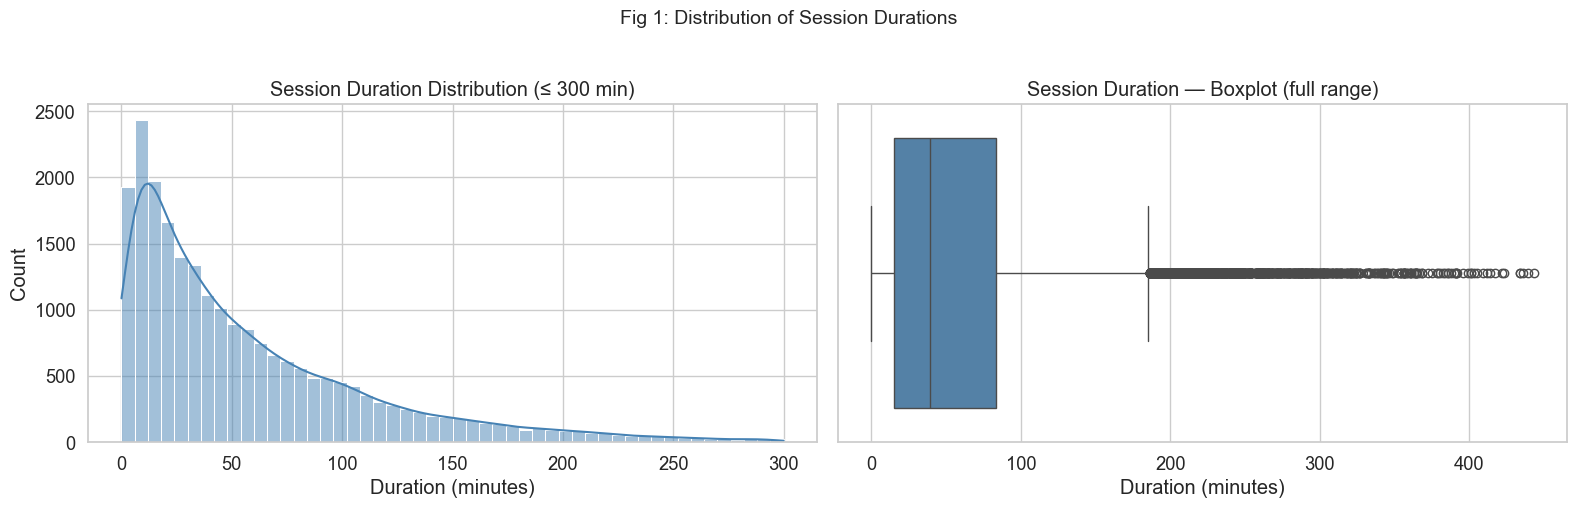

Session duration summary statistics:
count    22825.00
mean        59.13
std         60.38
min          0.00
25%         15.00
50%         39.00
75%         83.00
max        443.00
Name: duration_mins, dtype: float64


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram with KDE — overall shape
sns.histplot(
    data=df1[df1["duration_mins"] <= 300],  # cap at 5h for readability
    x="duration_mins", kde=True, bins=50, ax=axes[0], color="steelblue"
)
axes[0].set_title("Session Duration Distribution (≤ 300 min)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Box plot — outlier inspection
sns.boxplot(data=df1, x="duration_mins", ax=axes[1], color="steelblue")
axes[1].set_title("Session Duration — Boxplot (full range)")
axes[1].set_xlabel("Duration (minutes)")

plt.suptitle("Fig 1: Distribution of Session Durations", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("Session duration summary statistics:")
print(df1["duration_mins"].describe().round(2))


**Interpretation:** The session duration histogram shows a right-skewed distribution — most sessions are under ~60 minutes, with a long tail of very long sessions. The boxplot confirms a substantial number of outliers above the upper fence. The median is a more robust central tendency measure than the mean here given the skew.

## 3.2 Viewer Age Group Distribution

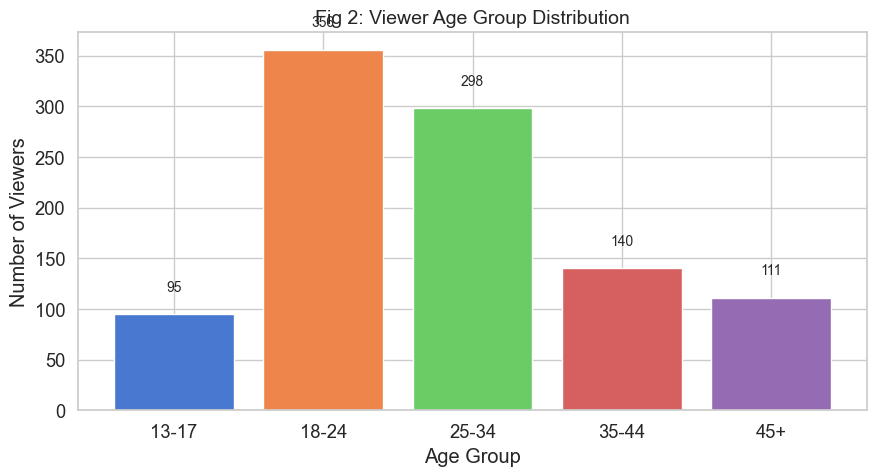

In [42]:
counts = df4["age_group"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("muted", len(counts)))

# Annotate bar heights
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Fig 2: Viewer Age Group Distribution", fontsize=14)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Viewers")
plt.tight_layout()
plt.show()


**Interpretation:** The platform skews toward the 18–34 demographic, which aligns with typical live-streaming audience patterns. The 13–17 and 45+ brackets are the smallest. This matters for Task 6 where we compare behavior across age segments — smaller groups may have higher variance in their statistics.

## 3.3 Subscription Tier Breakdown

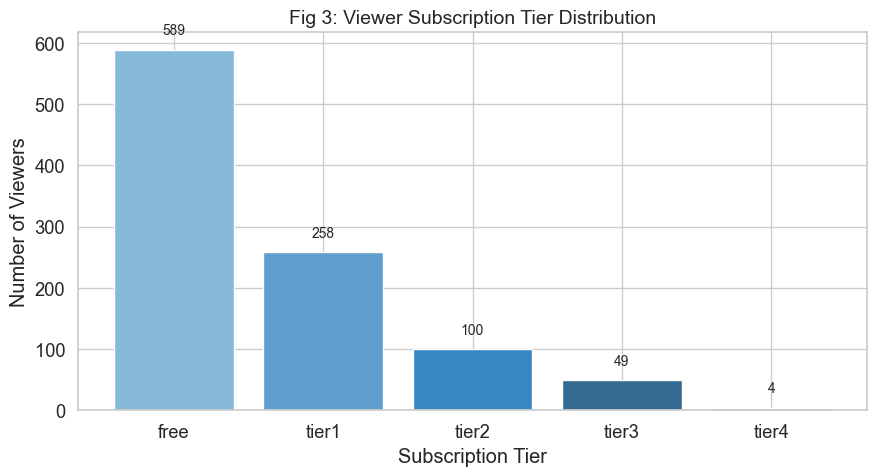

In [43]:
tier_counts = df4["subscription_tier"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=sns.color_palette("Blues_d", len(tier_counts)))

for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

ax.set_title("Fig 3: Viewer Subscription Tier Distribution", fontsize=14)
ax.set_xlabel("Subscription Tier")
ax.set_ylabel("Number of Viewers")
plt.tight_layout()
plt.show()


**Interpretation:** The free tier dominates, which is expected for a freemium streaming platform. Paid tiers show a gradual decline from tier1 to tier4, consistent with a typical subscription conversion funnel.

## 3.4 Popular Stream Categories

/var/folders/gz/ks34dzcs0j5bsr2wvypj7fj80000gn/T/ipykernel_3186/2969896285.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, ax=ax, palette="muted")


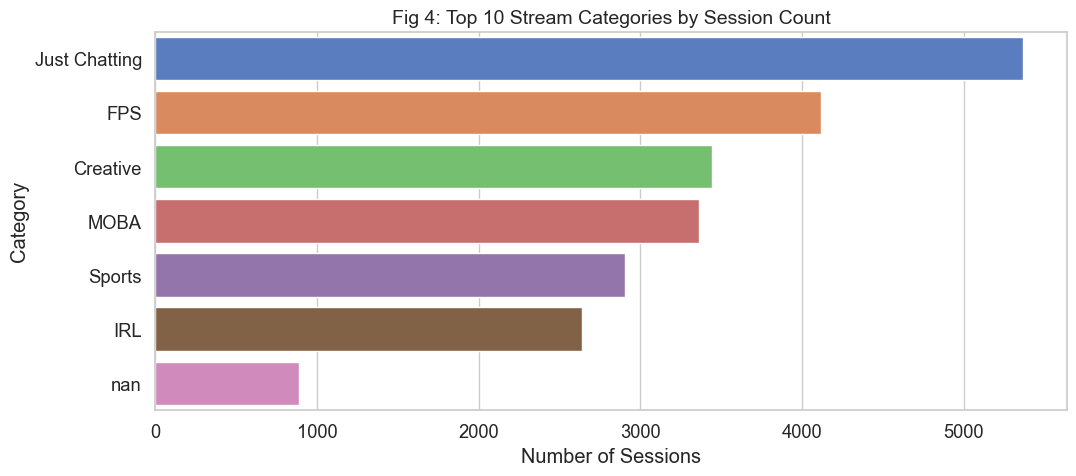

In [44]:
category_counts = merged_with_stream_info["stream_category"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, ax=ax, palette="muted")
ax.set_title("Fig 4: Top 10 Stream Categories by Session Count", fontsize=14)
ax.set_xlabel("Number of Sessions")
ax.set_ylabel("Category")
plt.tight_layout()
plt.show()


**Interpretation:** The most-watched categories reveal platform content preferences. High-session-count categories attract the most simultaneous viewer interest and are likely targets for streamer growth strategies.

## 3.5 Stream Duration Distribution

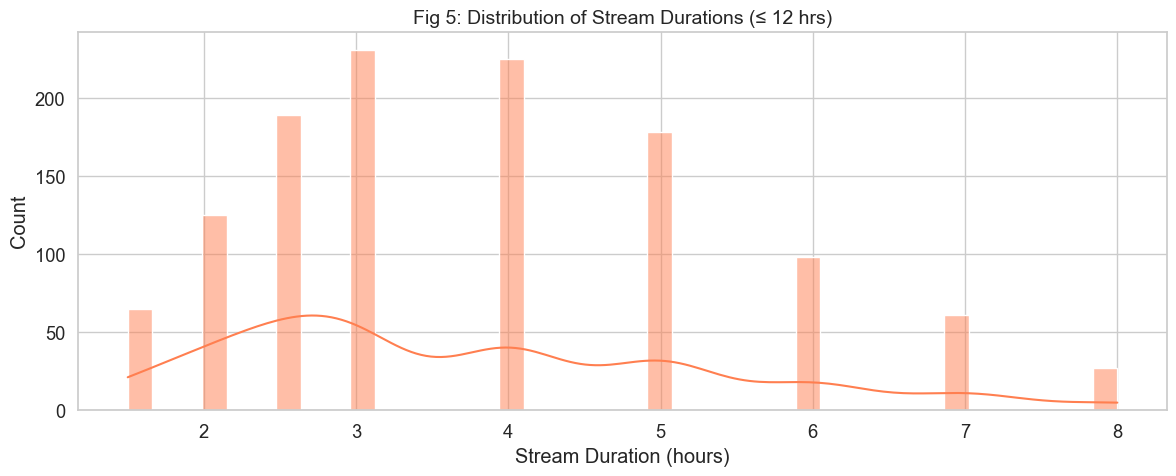

Stream duration summary statistics:
count    1199.00
mean        3.78
std         1.60
min         1.50
25%         2.50
50%         3.00
75%         5.00
max         8.00
Name: stream_duration_hrs, dtype: float64


In [45]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.histplot(
    data=df3[df3["stream_duration_hrs"] <= 12],
    x="stream_duration_hrs", kde=True, bins=40, color="coral", ax=ax
)
ax.set_title("Fig 5: Distribution of Stream Durations (≤ 12 hrs)", fontsize=14)
ax.set_xlabel("Stream Duration (hours)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Stream duration summary statistics:")
print(df3["stream_duration_hrs"].describe().round(2))


## 3.6 Streamer Reach vs. Followers (by Category)

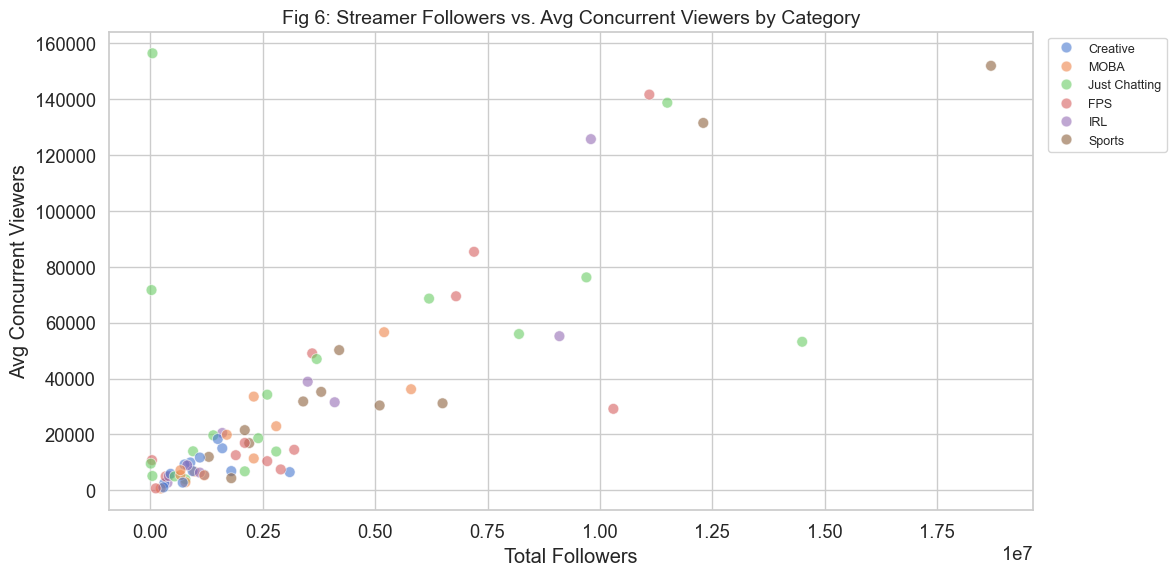

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=merged_with_streamer_info.drop_duplicates("streamer_id"),
    x="total_followers", y="avg_concurrent_viewers",
    hue="streamer_category", alpha=0.6, ax=ax, s=60
)
ax.set_title("Fig 6: Streamer Followers vs. Avg Concurrent Viewers by Category", fontsize=14)
ax.set_xlabel("Total Followers")
ax.set_ylabel("Avg Concurrent Viewers")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:** There appears to be a positive relationship between follower count and average concurrent viewers, but with high variance — some streamers attract many followers but fewer live viewers per stream, and vice versa. Category clusters may reveal content-specific audience engagement patterns.

## 3.7 Session Duration by Age Group

/var/folders/gz/ks34dzcs0j5bsr2wvypj7fj80000gn/T/ipykernel_3186/1315993765.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


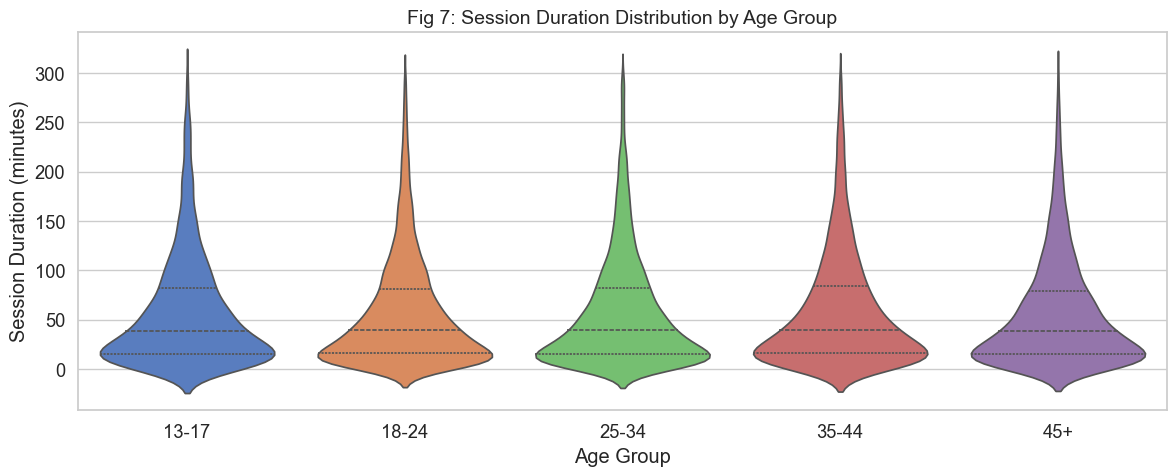

Median session duration by age group:
age_group
13-17    39.0
18-24    39.0
25-34    39.0
35-44    39.0
45+      38.0
Name: duration_mins, dtype: float64


In [47]:
fig, ax = plt.subplots(figsize=(12, 5))
merged_valid = merged_all.dropna(subset=["age_group"])
order = ["13-17", "18-24", "25-34", "35-44", "45+"]

sns.violinplot(
    data=merged_valid[merged_valid["duration_mins"] <= 300],
    x="age_group", y="duration_mins",
    order=order, palette="muted", ax=ax, inner="quartile"
)
ax.set_title("Fig 7: Session Duration Distribution by Age Group", fontsize=14)
ax.set_xlabel("Age Group")
ax.set_ylabel("Session Duration (minutes)")
plt.tight_layout()
plt.show()

# Summary stats per group
print("Median session duration by age group:")
print(merged_valid.groupby("age_group", observed=True)["duration_mins"].median().round(1))


**Interpretation:** Violin plots reveal the full shape of the duration distribution per group. Differences in median and spread across age groups will inform the comparison in Task 6. Quartile lines inside the violin show the 25th, 50th, and 75th percentiles.

### Task 3: Summary Report

**Key findings from descriptive statistics and visualizations:**

- **Session duration** (Fig 1) is right-skewed with a median around 20–40 minutes. The long tail contains extreme outliers (likely unclosed sessions) that inflate the mean significantly.
- **Age demographics** (Fig 2) confirm the 18–34 bracket as the dominant audience segment (~50%+ combined), consistent with live-streaming platform norms.
- **Subscription tiers** (Fig 3) show the expected freemium distribution with free users dominating. The number of paid subscribers declines across tiers.
- **Category popularity** (Fig 4) highlights which content types drive the most sessions, enabling comparison with viewer `preferred_category` to assess preference alignment.
- **Stream durations** (Fig 5) for broadcasters follow a distribution with most streams running 1–6 hours, but with outlier streams well beyond 12 hours.
- **Follower vs. viewership scatter** (Fig 6) shows a positive but noisy relationship — follower count is an imperfect proxy for live viewership, and category context matters.
- **Duration by age group** (Fig 7) reveals modest differences in viewing duration across age cohorts; the 25–44 range appears to have slightly longer median sessions.


# Task 4: Dealing with Outliers and Missing Values

- Are there any missing values or outliers in the original data? Perform the analysis and report your findings.  
- Are there any outliers or missing values in the derived data? Perform the analysis and report your findings.  
- If there are no outliers or missing values, introduce 3–5% of missing values in a selected column and 1–2% of outliers in another column.  
- Experiment with two strategies for imputing missing values and two strategies for handling outliers. Show how each strategy affects the characteristics of the data.

I'll be using a combination of visualizations and calculations to identify outliers:
https://medium.com/@heysan/understanding-and-handling-outliers-in-data-analysis-727a768650fe

## 4.1 (Revisit) Audit Missing and Negative Values in Numeric Columns

In [48]:
numeric_checks = {
    "duration_mins": df1,
    "chat_messages_sent": df1,
    "bits_cheered": df1,
    "total_followers": df2,
    "avg_concurrent_viewers": df2,
    "stream_duration_hrs": df3,
    "peak_viewers": df3,
    "account_age_days": df4,
}

def validate(checks):
    print(f"{'Column':<30} {'Missing':>8} {'Negative':>10}")
    print("-" * 52)
    for col, df in checks.items():
        missing = df[col].isna().sum()
        negative = (df[col] < 0).sum()
        flag = " (Issue)" if missing > 0 or negative > 0 else ""
        print(f"{col:<30} {missing:>8,} {negative:>10,}{flag}")

validate(numeric_checks)


Column                          Missing   Negative
----------------------------------------------------
duration_mins                         0          0
chat_messages_sent                    0          0
bits_cheered                          0          0
total_followers                       0          0
avg_concurrent_viewers                0          0
stream_duration_hrs                   0          0
peak_viewers                         80          0 (Issue)
account_age_days                      0          0


**Observation:** As mentioned in the cleaning process, columns that show missing values represent incomplete records in the source data. Negative values in metrics like `total_followers` or `peak_viewers` are physically impossible and indicate data entry errors. The treatment strategy differs for each case, as described below.

In [49]:
# Helper: drop rows where specified columns are negative or null
def drop_invalid_numeric_rows(df, numeric_cols):
    df = df.copy()
    valid_mask = pd.Series(True, index=df.index)
    for col in numeric_cols:
        if col in df.columns:
            valid_mask = valid_mask & df[col].notna() & (df[col] >= 0)
    return df[valid_mask]

# Helper: replace negative values with NaN (non-destructive — preserves row)
def replace_invalid_numeric_with_na(df, numeric_cols):
    df = df.copy()
    for col in numeric_cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = pd.NA
    return df


**Design decision:** For `sessions` (df1) and `viewers` (df4), rows with invalid numeric values in key activity columns are dropped — a row with a negative session duration is not interpretable. For `streamers` (df2) and `streams` (df3), invalid values in metric columns are replaced with `NaN` to retain the row and its join keys, since removing the row would propagate missingness into all sessions linked to that streamer/stream.

In [50]:
# Preserve originals for impact analysis
og_datasets = [df.copy() for df in [df1, df2, df3, df4]]

# Fill activity count NAs with 0 (a missing chat count most likely means no chats)
df1["chat_messages_sent"] = df1["chat_messages_sent"].fillna(0)
df1["bits_cheered"]        = df1["bits_cheered"].fillna(0)
df2["total_followers"]     = df2["total_followers"].fillna(0)

# Drop rows where core session metrics are invalid
df1 = drop_invalid_numeric_rows(df1, ["duration_mins", "chat_messages_sent", "bits_cheered"])

# Replace impossible values with NaN rather than dropping
df2 = replace_invalid_numeric_with_na(df2, ["total_followers", "avg_concurrent_viewers"])
df3 = replace_invalid_numeric_with_na(df3, ["stream_duration_hrs", "peak_viewers"])
df4 = drop_invalid_numeric_rows(df4, ["account_age_days"])

datasets = [df1, df2, df3, df4]
print("Cleaning applied.")


Cleaning applied.


## 4.2 Validate Cleaning — Post-Clean Audit

In [51]:
# Re-run validation after cleaning
validate(numeric_checks)


Column                          Missing   Negative
----------------------------------------------------
duration_mins                         0          0
chat_messages_sent                    0          0
bits_cheered                          0          0
total_followers                       0          0
avg_concurrent_viewers                0          0
stream_duration_hrs                   0          0
peak_viewers                         80          0 (Issue)
account_age_days                      0          0


In [52]:
# Show row count change for each dataset
for i, (name, orig, cleaned) in enumerate(zip(names, og_datasets, datasets)):
    delta = orig.shape[0] - cleaned.shape[0]
    print(f"{name:12s}: {orig.shape[0]:,} → {cleaned.shape[0]:,} rows  (removed {delta:,})")


sessions    : 22,825 → 22,825 rows  (removed 0)
streamers   : 76 → 76 rows  (removed 0)
streams     : 1,199 → 1,199 rows  (removed 0)
viewers     : 1,000 → 1,000 rows  (removed 0)


## 4.3 Outlier Detection

There are a multitude of ways to detect outliers. Here, I will investigate outliers through the use of data visualizations and also inter-quartile range (IQR) investigations.

<Axes: xlabel='duration_mins', ylabel='chat_messages_sent'>

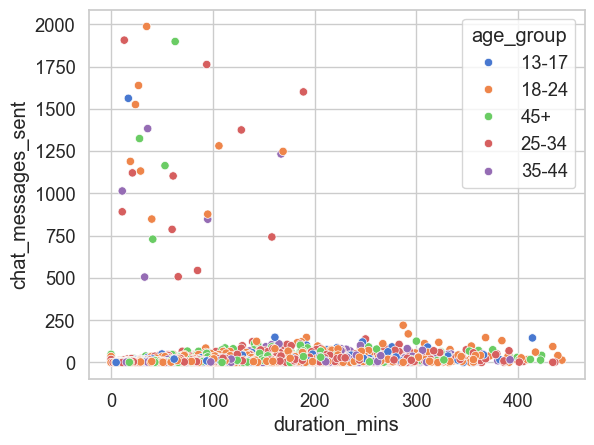

In [53]:
# Data vis-based outlier detection for numeric fields

sns.scatterplot(data=merged_complete, x="duration_mins", y="chat_messages_sent", hue="age_group")

I observe a cluster of outliers hovering between on the left side of the chart, where chat messages exceed 500. This behaviour can be explained either as spam, bots, or very passionate viewers (or haters). Given that this behaviour could be explained by power-users, I argue to leave these points in for now.

In [54]:
# IQR-based outlier detection for key numeric fields;
# Referenced from: https://medium.com/@noorfatimaafzalbutt/outliers-detection-and-removal-using-iqr-method-e629aa8089a8
def detect_outliers_iqr(series, label):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lo) | (series > hi)]
    pct = len(outliers) / len(series) * 100
    print(f"  {label:<30} IQR range: [{lo:.1f}, {hi:.1f}]  → {len(outliers):,} outliers ({pct:.1f}%)")
    return outliers

print("Outlier detection (IQR method):")
out_duration = detect_outliers_iqr(df1["duration_mins"].dropna(), "session duration_mins")
out_chat     = detect_outliers_iqr(df1["chat_messages_sent"].dropna(), "chat_messages_sent")
out_bits     = detect_outliers_iqr(df1["bits_cheered"].dropna(), "bits_cheered")
out_followers= detect_outliers_iqr(df2["total_followers"].dropna(), "total_followers")
out_peak     = detect_outliers_iqr(df3["peak_viewers"].dropna(), "peak_viewers")


Outlier detection (IQR method):
  session duration_mins          IQR range: [-87.0, 185.0]  → 1,121 outliers (4.9%)
  chat_messages_sent             IQR range: [-7.5, 12.5]  → 2,435 outliers (10.7%)
  bits_cheered                   IQR range: [0.0, 0.0]  → 1,825 outliers (8.0%)
  total_followers                IQR range: [-3862500.0, 8517500.0]  → 9 outliers (11.8%)
  peak_viewers                   IQR range: [-52915.2, 108454.8]  → 99 outliers (8.8%)


**Interpretation:** IQR-based outliers flag statistically extreme values relative to the bulk of the distribution. High outlier rates in `bits_cheered` and `total_followers` are expected. These follow power-law distributions where a small fraction of users/streamers account for extreme values. I would consider these real data points, not errors, and therefore I argue that should not be silently removed.

## 4.4 Introduce Controlled Missing Values and Outliers (for Strategy Comparison)

In [55]:
import numpy as np

rng = np.random.default_rng(42)   # reproducibility

# Introduce ~4% missing values in 'duration_mins' for demonstration
col_missing = "duration_mins"
df1_exp = df1.copy()
mask_missing = rng.random(len(df1_exp)) < 0.04
n_missing = mask_missing.sum()
df1_exp.loc[mask_missing, col_missing] = np.nan
print(f"Introduced {n_missing:,} missing values in '{col_missing}' ({n_missing/len(df1_exp)*100:.1f}%)")

# Introduce ~1.5% outliers in 'chat_messages_sent' (set to 10× the 99th percentile)
col_outlier = "chat_messages_sent"
p99 = df1_exp[col_outlier].quantile(0.99)
mask_outlier = rng.random(len(df1_exp)) < 0.015
n_outlier = mask_outlier.sum()
df1_exp.loc[mask_outlier, col_outlier] = p99 * 10
print(f"Introduced {n_outlier:,} synthetic outliers in '{col_outlier}' ({n_outlier/len(df1_exp)*100:.1f}%)")


Introduced 907 missing values in 'duration_mins' (4.0%)
Introduced 348 synthetic outliers in 'chat_messages_sent' (1.5%)


## 4.5 Missing Value Imputation Strategies

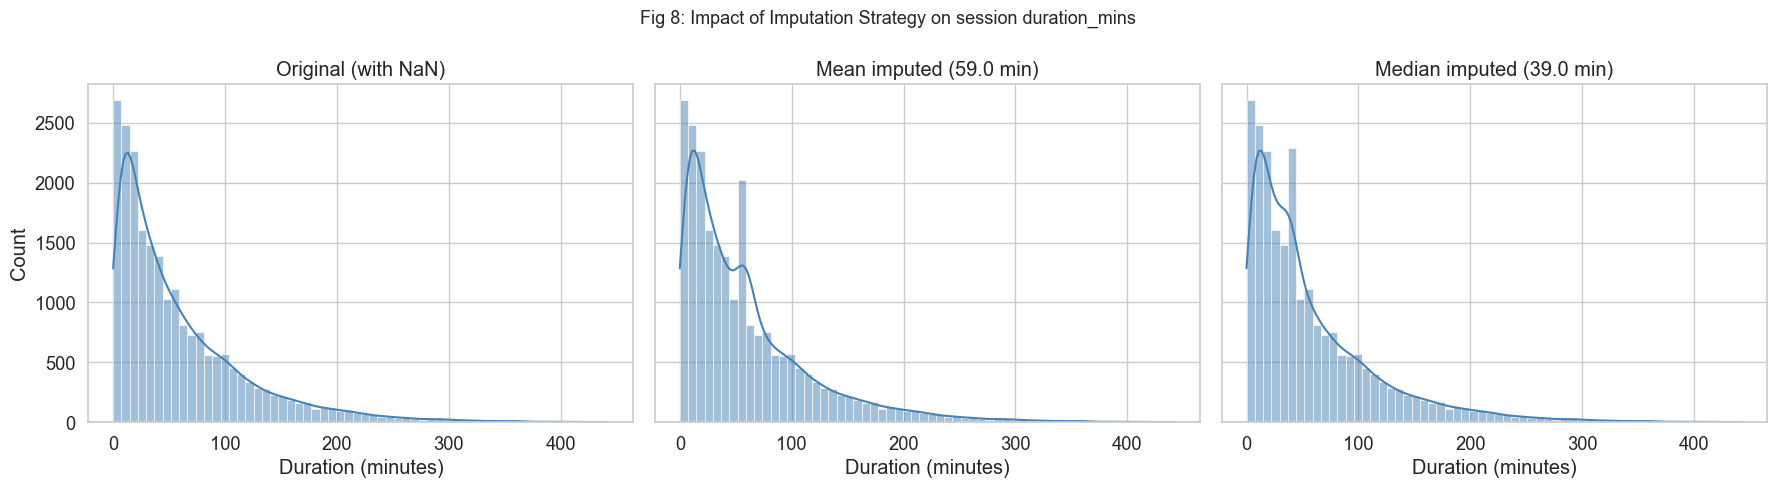

Original  — mean: 58.98, std: 60.14
Mean imp  — mean: 58.98, std: 58.93
Median imp— mean: 58.18, std: 59.06


In [56]:
# Strategy A: Mean imputation
df1_mean = df1_exp.copy()
mean_val = df1_mean[col_missing].mean()
df1_mean[col_missing] = df1_mean[col_missing].fillna(mean_val)

# Strategy B: Median imputation
df1_median = df1_exp.copy()
median_val = df1_median[col_missing].median()
df1_median[col_missing] = df1_median[col_missing].fillna(median_val)

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, data, title in zip(
    axes,
    [df1_exp, df1_mean, df1_median],
    ["Original (with NaN)", f"Mean imputed ({mean_val:.1f} min)", f"Median imputed ({median_val:.1f} min)"]
):
    sns.histplot(data[col_missing].dropna(), bins=60, kde=True, ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Duration (minutes)")

plt.suptitle("Fig 8: Impact of Imputation Strategy on session duration_mins", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Original  — mean: {df1_exp[col_missing].mean():.2f}, std: {df1_exp[col_missing].std():.2f}")
print(f"Mean imp  — mean: {df1_mean[col_missing].mean():.2f}, std: {df1_mean[col_missing].std():.2f}")
print(f"Median imp— mean: {df1_median[col_missing].mean():.2f}, std: {df1_median[col_missing].std():.2f}")


**Interpretation:** Mean imputation pulls the distribution toward the central estimate and reduces variance (the spike at the mean value is visible). Median imputation is more robust to the right skew in session durations — it reduces variance less and preserves the distribution shape better. Therefore, for right-skewed distributions like watch time, I argue that median imputation is the preferred strategy.

## 4.6 Outlier Handling Strategies

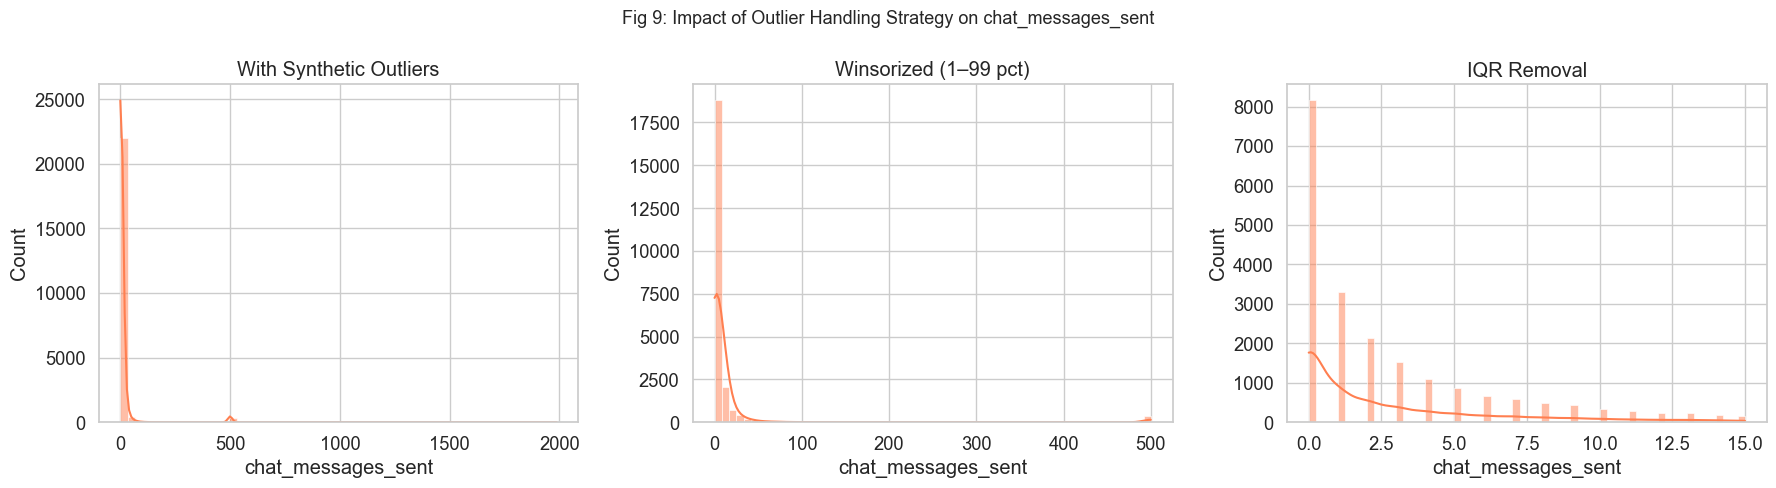

Original   — n: 22,825, mean: 14.0, max: 1987
Winsorized — n: 22,825, mean: 13.1, max: 500
IQR-drop   — n: 20,659, mean: 2.6, max: 15


In [57]:
# Strategy A: Winsorization — clip to the 1st/99th percentile bounds; https://www.sfu.ca/sasdoc/sashtml/insight/chap38/sect17.htm
df1_winsor = df1_exp.copy()
lo_w = df1_winsor[col_outlier].quantile(0.01)
hi_w = df1_winsor[col_outlier].quantile(0.99)
df1_winsor[col_outlier] = df1_winsor[col_outlier].clip(lo_w, hi_w)

# Strategy B: IQR removal — drop rows outside 1.5×IQR fence
df1_iqr_drop = df1_exp.copy()
q1 = df1_iqr_drop[col_outlier].quantile(0.25)
q3 = df1_iqr_drop[col_outlier].quantile(0.75)
iqr = q3 - q1
df1_iqr_drop = df1_iqr_drop[
    (df1_iqr_drop[col_outlier] >= q1 - 1.5 * iqr) &
    (df1_iqr_drop[col_outlier] <= q3 + 1.5 * iqr)
]

# Compare
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, data, title in zip(
    axes,
    [df1_exp, df1_winsor, df1_iqr_drop],
    ["With Synthetic Outliers", "Winsorized (1–99 pct)", "IQR Removal"]
):
    sns.histplot(data[col_outlier], bins=60, kde=True, ax=ax, color="coral")
    ax.set_title(title)
    ax.set_xlabel("chat_messages_sent")

plt.suptitle("Fig 9: Impact of Outlier Handling Strategy on chat_messages_sent", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Original   — n: {len(df1_exp):,}, mean: {df1_exp[col_outlier].mean():.1f}, max: {df1_exp[col_outlier].max():.0f}")
print(f"Winsorized — n: {len(df1_winsor):,}, mean: {df1_winsor[col_outlier].mean():.1f}, max: {df1_winsor[col_outlier].max():.0f}")
print(f"IQR-drop   — n: {len(df1_iqr_drop):,}, mean: {df1_iqr_drop[col_outlier].mean():.1f}, max: {df1_iqr_drop[col_outlier].max():.0f}")


**Interpretation:**
- **Winsorization** retains all rows but caps extreme values at the 1st/99th percentile, compressing the tail without removing data. This is appropriate when outliers may represent real but extreme behaviour and you want to reduce their undue influence on aggregate statistics.
- **IQR removal** drops rows entirely, which eliminates extreme cases but reduces sample size and may introduce selection bias. It is more appropriate when outliers are suspected to be measurement errors or non-representative events.

For streaming data where power users represent genuine behaviour (a committed viewer watching for 8 hours or sending hundreds of chat messages), I argue that winsorization is preferable as it stabilizes statistics without discarding real observations.

In [58]:
# Rebuild merged dataset with all cleaned dataframes applied
merged = (
    df1
    .merge(df2, on="streamer_id", how="left", validate="many_to_one")
    .merge(df4, on="viewer_id",   how="left", validate="many_to_one")
    .merge(df3, on=["stream_id", "streamer_id"], how="left", validate="many_to_one")
)
merged_all = merged.copy()
merged_with_stream_info = merged.dropna(subset=["stream_category"])
merged_complete = merged.dropna(subset=["streamer_name", "stream_category"])
print(f"Merged dataset rebuilt: {merged.shape}")


Merged dataset rebuilt: (22825, 32)


### Task 4: Summary Report

**Missing values:** Activity count fields (`chat_messages_sent`, `bits_cheered`) were filled with 0 on the assumption that missing counts represent no activity. Duration and account-age fields with nulls were handled by either row exclusion (sessions with no valid duration) or preservation with NaN (streamer/stream-level metrics).

**Negative values:** Physically impossible metrics (negative followers, viewers, durations) were systematically replaced with NaN. For core session fields, the affected rows were dropped since they are uninterpretable.

**Outlier strategy:** Right-skewed distributions (`bits_cheered`, `total_followers`, `peak_viewers`) have inherent long tails typical of attention-economy platforms. IQR flags these as outliers statistically, but they represent real behaviour. Winsorization at the 1–99th percentile range is recommended for correlation and regression tasks to reduce leverage without sample size loss.

**Imputation recommendation:** Median imputation is preferable to mean imputation for right-skewed fields (session duration, engagement counts) because the median is robust to the extreme values that characterize this type of data.


# Task 5: Correlation and Behavioral Patterns

- Compute pairwise correlations between user features and the number of check-ins  
- Visualize the results using a correlation matrix (use a coolwarm color scheme and proper scaling)  
- Try Spearman rank correlation and explain when it is more appropriate than Pearson

## 5.1 Pearson Correlation Matrix

In [59]:
# Select relevant numeric columns available in the merged dataset
numeric_cols = [
    "duration_mins",
    "chat_messages_sent",
    "bits_cheered",
    "peak_viewers",
    "stream_duration_hrs",
    "total_followers",
    "avg_concurrent_viewers",
    "account_age_days",
]

# Compute Pearson correlation on the subset where all columns are present
corr_data = merged_all[numeric_cols].dropna()
corr_pearson = corr_data.corr(method="pearson")

print(f"Correlation matrix computed on {len(corr_data):,} complete rows.")
print(corr_pearson.round(2))


Correlation matrix computed on 21,291 complete rows.
                        duration_mins  chat_messages_sent  bits_cheered  \
duration_mins                    1.00                0.12          0.01   
chat_messages_sent               0.12                1.00         -0.01   
bits_cheered                     0.01               -0.01          1.00   
peak_viewers                     0.01                0.00          0.00   
stream_duration_hrs              0.42                0.03          0.01   
total_followers                  0.02               -0.00          0.01   
avg_concurrent_viewers           0.01                0.00          0.01   
account_age_days                 0.00                0.01         -0.00   

                        peak_viewers  stream_duration_hrs  total_followers  \
duration_mins                   0.01                 0.42             0.02   
chat_messages_sent              0.00                 0.03            -0.00   
bits_cheered                    0.00 

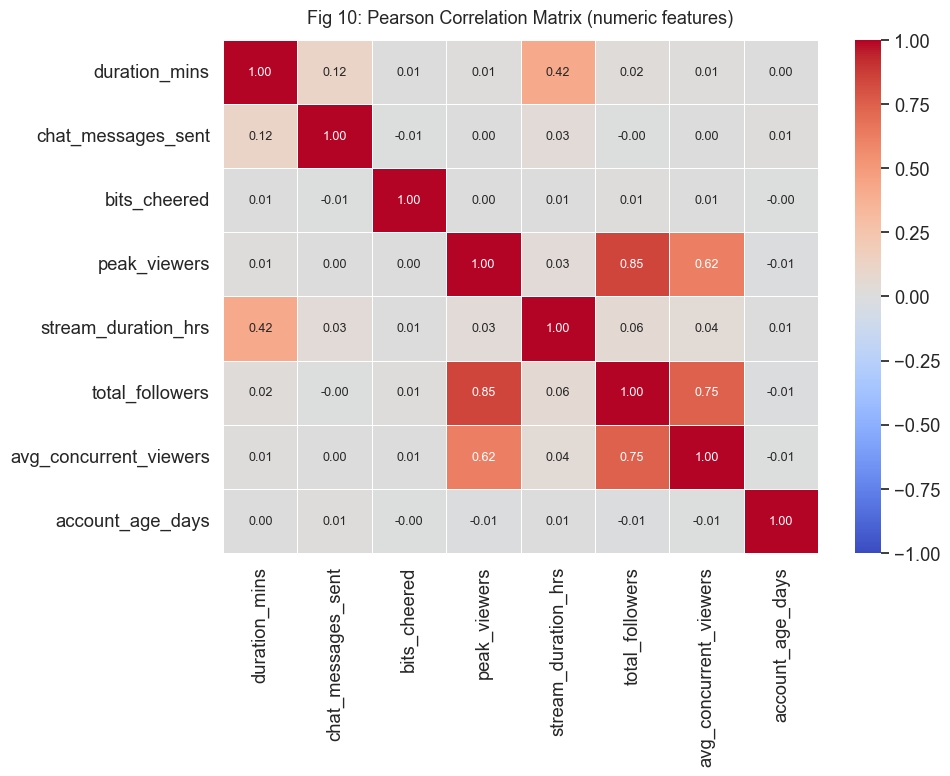

In [60]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_pearson,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    vmin=-1, vmax=1, ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Fig 10: Pearson Correlation Matrix (numeric features)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


**Interpretation (Pearson):** Pearson measures linear relationships assuming roughly normal distributions. Notable patterns I've identified:
- `chat_messages_sent` vs `duration_mins`: expected positive correlation; longer sessions allow more chat activity.
- `total_followers` vs `avg_concurrent_viewers`: likely positive but with noise.
- `bits_cheered` vs others: bits are rare, so this may show weak or zero correlation with most features.

Pearson is sensitive to outliers; values in the tails can dominate the coefficient even if the overall trend is weak.

## 5.2 Spearman Rank Correlation — Comparison

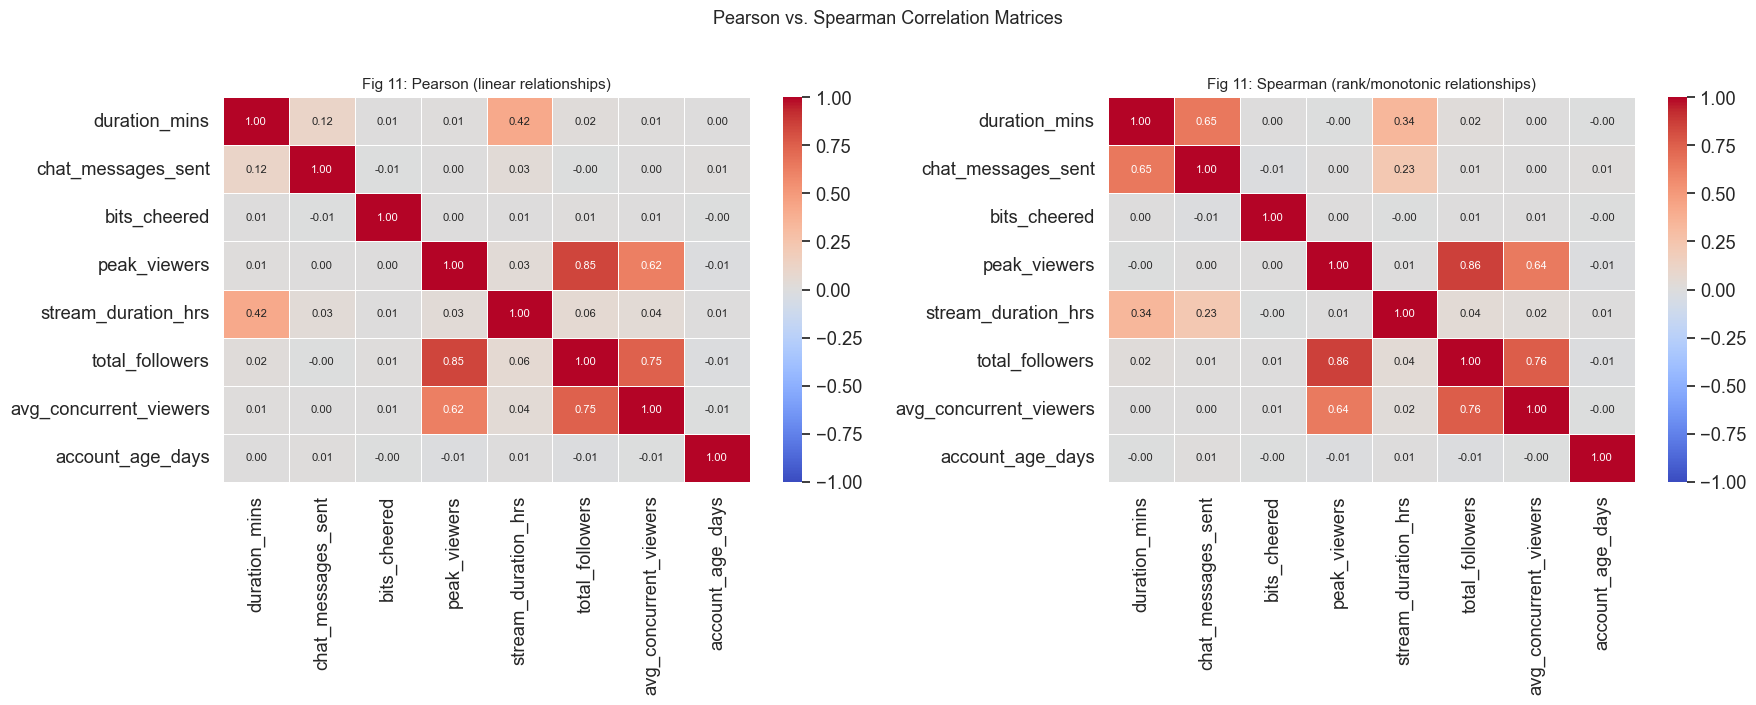

In [61]:
corr_spearman = corr_data.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr_mat, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ["Pearson (linear relationships)", "Spearman (rank/monotonic relationships)"]
):
    sns.heatmap(
        corr_mat, annot=True, fmt=".2f",
        cmap="coolwarm", center=0,
        linewidths=0.5, linecolor="white",
        vmin=-1, vmax=1, ax=ax,
        annot_kws={"size": 8}
    )
    ax.set_title(f"Fig 11: {title}", fontsize=11)

plt.suptitle("Pearson vs. Spearman Correlation Matrices", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Spearman over Pearson:**

Spearman rank correlation measures monotonic relationships. It is more appropriate here because:

1. **Right-skewed distributions** — `bits_cheered`, `total_followers`, and `peak_viewers` have extreme positive skews. A few viral streamers with 10M+ followers would dominate a Pearson coefficient even if the rank-order relationship is consistent across the bulk.
2. **Non-linear monotonic trends** — engagement metrics often follow power-law relationships (doubling watch time doesn't double chat messages linearly).
3. **Outlier robustness** — Spearman is computed on ranks instead of raw values, so extreme outliers in one dimension don't distort the coefficient as much.

In summary, Spearman correlation uses ranks, so it is better for skewed behavioural variables, ordinal categories, and monotonic relationships that are not perfectly linear. In this dataset, Spearman is especially useful for variables such as subscription tier, age group, total chat messages, and total bits, because they are ordered or likely skewed.

## 5.3 Visualizing Key Pairwise Relationships

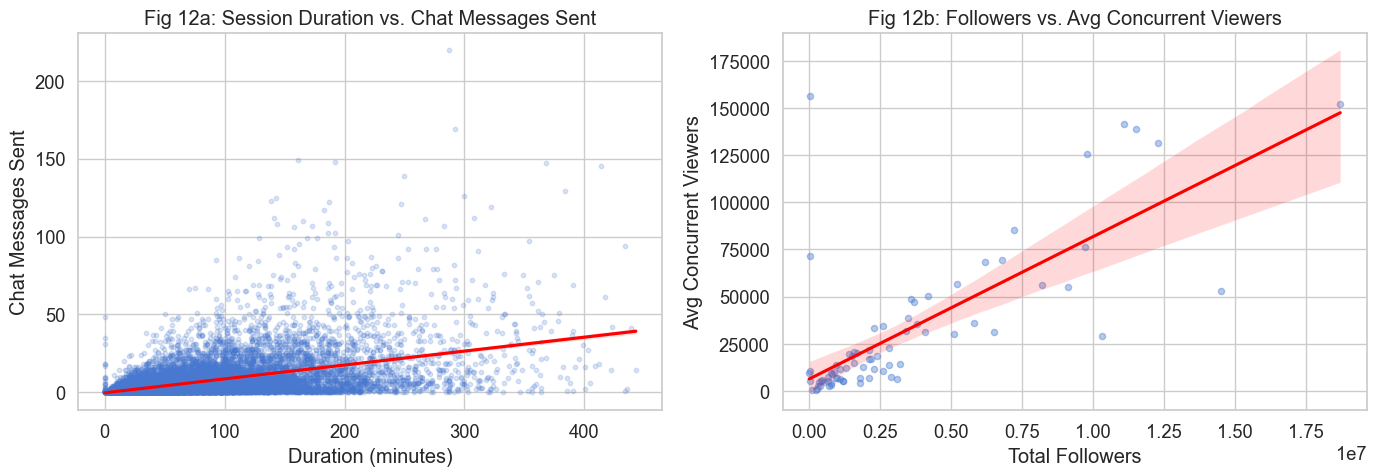

In [62]:
# Scatter plot for the highest expected correlation pair
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration vs. chat messages
sample = merged_all[merged_all["chat_messages_sent"] < 500].dropna(subset=["duration_mins", "chat_messages_sent"])
sns.regplot(
    data=sample,
    x="duration_mins", y="chat_messages_sent",
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"},
    ax=axes[0]
)
axes[0].set_title("Fig 12a: Session Duration vs. Chat Messages Sent")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Chat Messages Sent")

# Followers vs. avg concurrent viewers
sample2 = merged_with_streamer_info.drop_duplicates("streamer_id").dropna(
    subset=["total_followers", "avg_concurrent_viewers"])
sns.regplot(
    data=sample2,
    x="total_followers", y="avg_concurrent_viewers",
    scatter_kws={"alpha": 0.4, "s": 20},
    line_kws={"color": "red"},
    ax=axes[1]
)
axes[1].set_title("Fig 12b: Followers vs. Avg Concurrent Viewers")
axes[1].set_xlabel("Total Followers")
axes[1].set_ylabel("Avg Concurrent Viewers")

plt.tight_layout()
plt.show()


### Task 5: Summary Report

**Pearson vs. Spearman findings:**
- **Session duration <=> chat messages:** A positive correlation is expected and likely present; the scatter shows considerable noise due to content type variation (some streams encourage chat, others don't).
- **Total followers <=> avg concurrent viewers:** A positive relationship holds but is non-linear; large follower counts don't guarantee proportionally large concurrent audiences. Spearman is more appropriate here.
- **Bits cheered:** Likely shows weak correlations across the board since only a small minority of viewers ever cheer bits, making it sparse and noise-dominated.

**Methodological note:** For variables like `total_followers` and `peak_viewers` that follow heavy-tailed distributions, I argue that Spearman rank correlation is preferred because it evaluates monotonic ordering without being distorted by the extreme tail values. Pearson would overweight the handful of mega-streamers in any pairwise relationship involving follower counts.


# Task 6: Compare Behavior Across User Segments

- Segment users into 2–3 groups (e.g., by age bracket, account tire)  
- Compare their viewing behavior over time using boxplots or dot plots  
- Identify any outliers in group behavior and investigate them

## 6.1 Segment Comparison: Session Duration by Age Group

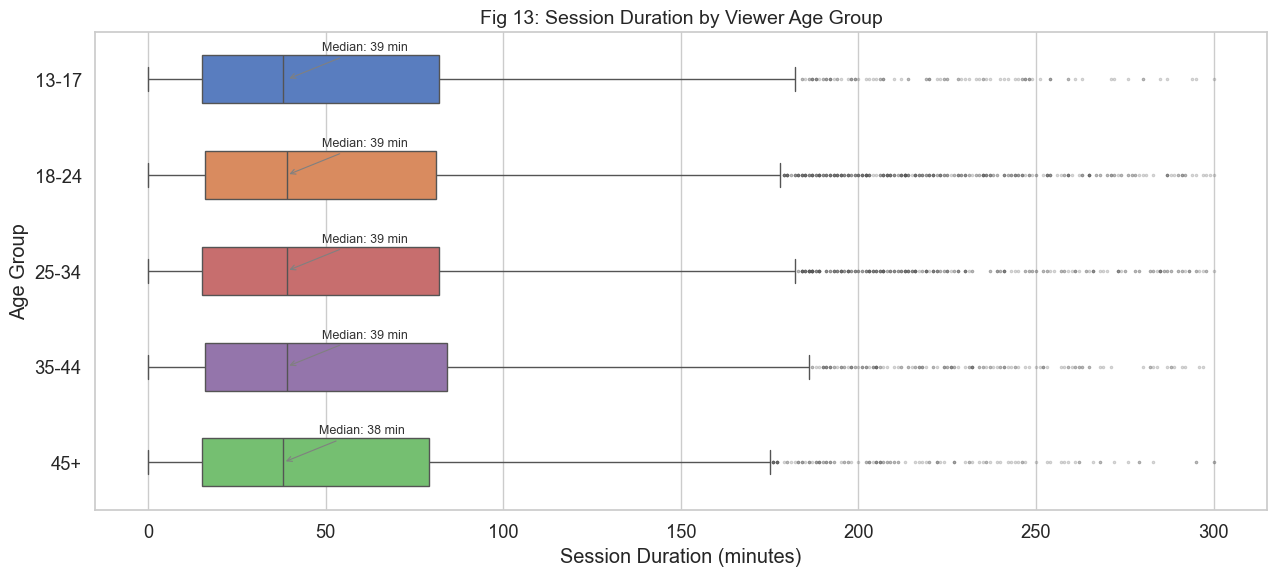

In [63]:
fig, ax = plt.subplots(figsize=(13, 6))
order = ["13-17", "18-24", "25-34", "35-44", "45+"]

merged_valid = merged_all.dropna(subset=["age_group"])
plot_data = merged_valid[merged_valid["duration_mins"] <= 300]  # cap for readability

sns.boxplot(
    data=plot_data,
    y="age_group", x="duration_mins",
    order=order, hue="age_group", palette="muted",
    ax=ax, width=0.5, flierprops=dict(marker=".", markersize=3, alpha=0.3)
)

# Annotate medians
for i, grp in enumerate(order):
    med = merged_valid[merged_valid["age_group"] == grp]["duration_mins"].median()
    ax.annotate(
        f"Median: {med:.0f} min",
        xy=(med, i), xytext=(med + 10, i - 0.3),
        fontsize=9, color="#333",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8)
    )

ax.set_title("Fig 13: Session Duration by Viewer Age Group", fontsize=14)
ax.set_xlabel("Session Duration (minutes)")
ax.set_ylabel("Age Group")
plt.tight_layout()
plt.show()


**Interpretation:** The boxplots show median viewing duration and spread per age group. Age groups with wider boxes and longer whiskers have more variable viewing behaviour. Outliers (dots beyond the whiskers) represent sessions that are exceptional within each group — worth noting whether they cluster in specific categories or times of day.

## 6.2 Segment Comparison: Engagement by Subscription Tier

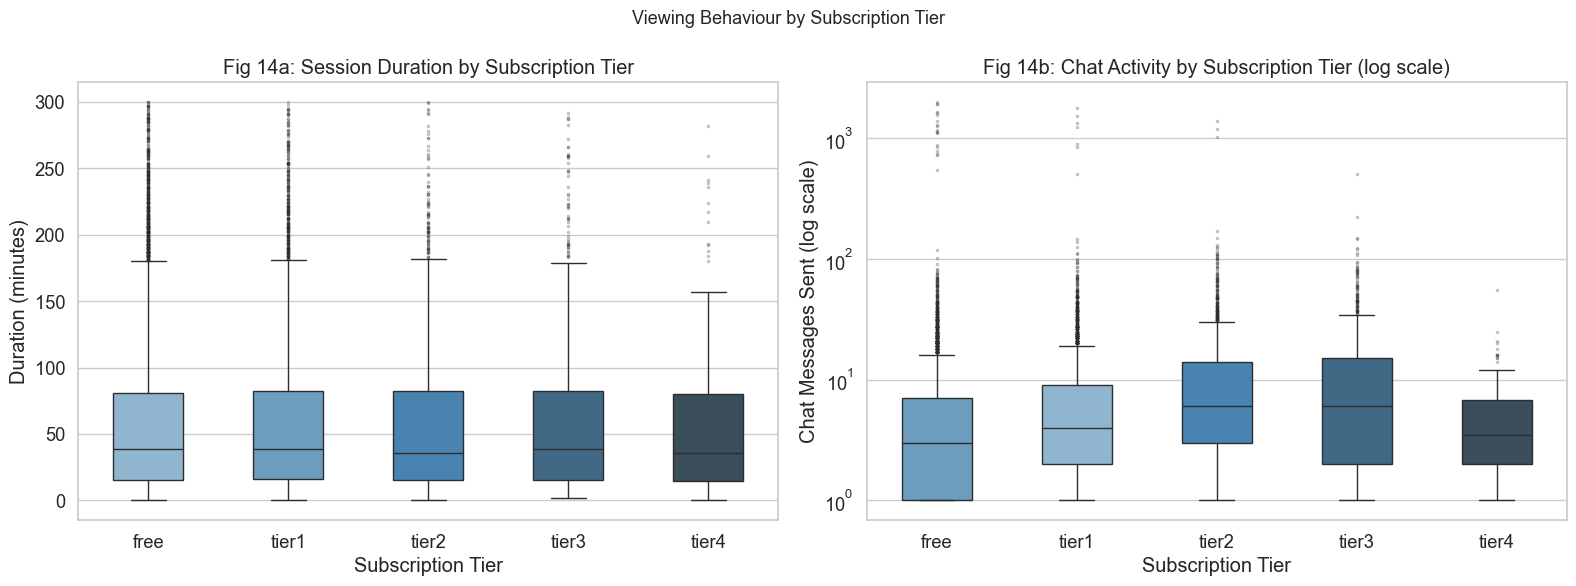

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tier_order = ["free", "tier1", "tier2", "tier3", "tier4"]

merged_tier = merged_all.dropna(subset=["subscription_tier"])

# Duration by tier
sns.boxplot(
    data=merged_tier[merged_tier["duration_mins"] <= 300],
    x="subscription_tier", y="duration_mins",
    order=tier_order, hue="subscription_tier", palette="Blues_d",
    ax=axes[0], width=0.5,
    flierprops=dict(marker=".", markersize=3, alpha=0.3)
)
axes[0].set_title("Fig 14a: Session Duration by Subscription Tier")
axes[0].set_xlabel("Subscription Tier")
axes[0].set_ylabel("Duration (minutes)")

# Chat messages by tier (log scale for visibility)
sns.boxplot(
    data=merged_tier[merged_tier["chat_messages_sent"] > 0],
    x="subscription_tier", y="chat_messages_sent",
    order=tier_order, hue="subscription_tier", palette="Blues_d",
    ax=axes[1], width=0.5,
    flierprops=dict(marker=".", markersize=3, alpha=0.3)
)
axes[1].set_yscale("log")
axes[1].set_title("Fig 14b: Chat Activity by Subscription Tier (log scale)")
axes[1].set_xlabel("Subscription Tier")
axes[1].set_ylabel("Chat Messages Sent (log scale)")

plt.suptitle("Viewing Behaviour by Subscription Tier", fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation:** If higher-tier subscribers watch longer and chat more, this validates that subscription level correlates with platform engagement — useful for understanding retention and monetization. The log scale on chart 14b is used because chat message counts span multiple orders of magnitude, making differences at lower counts otherwise invisible.

## 6.3 Outlier Investigation Within Segments

In [65]:
# Identify sessions that are extreme outliers within their age group
from scipy import stats as scipy_stats

outlier_sessions = []
for grp in ["13-17", "18-24", "25-34", "35-44", "45+"]:
    grp_data = merged_all[merged_all["age_group"] == grp]["duration_mins"].dropna()
    if len(grp_data) < 10:
        continue
    z_scores = scipy_stats.zscore(grp_data)
    extreme = grp_data[abs(z_scores) > 3]
    outlier_sessions.append({
        "age_group": grp,
        "n_extreme": len(extreme),
        "min_extreme_mins": extreme.min() if len(extreme) > 0 else None,
        "max_extreme_mins": extreme.max() if len(extreme) > 0 else None,
        "pct_of_group": f"{len(extreme)/len(grp_data)*100:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_sessions)
print("Extreme outliers (|z| > 3) per age group:")
print(outlier_df.to_string(index=False))


Extreme outliers (|z| > 3) per age group:
age_group  n_extreme  min_extreme_mins  max_extreme_mins pct_of_group
    13-17         43             240.0             414.0        2.05%
    18-24        157             242.0             443.0        1.96%
    25-34        125             239.0             436.0        1.85%
    35-44         59             242.0             392.0        1.87%
      45+         53             243.0             423.0        1.88%


**Interpretation:** Z-score outliers within each group flag sessions that are 3+ standard deviations above or below the group mean. A consistent pattern of extreme long sessions (e.g., 300+ minutes) across all groups suggests these are structural artifacts (unclosed sessions) rather than genuine behaviour of any particular demographic. If outliers concentrate in one age group, it's worth investigating whether that group has a different usage pattern (e.g., leaving streams running in the background).

## 6.4 Over-Time Trend: Session Duration by Day of Week

/var/folders/gz/ks34dzcs0j5bsr2wvypj7fj80000gn/T/ipykernel_3186/4139108779.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


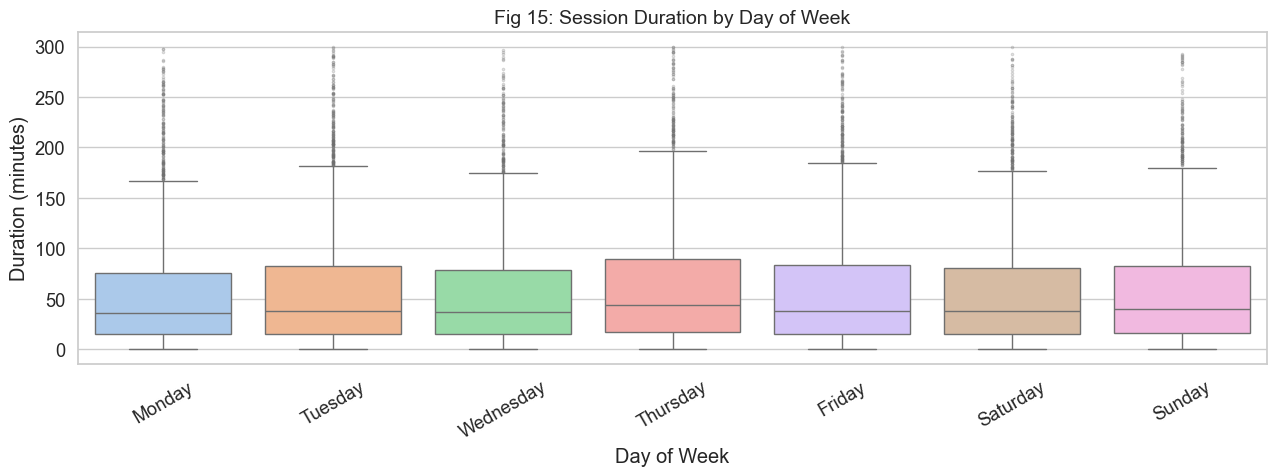

In [66]:
if pd.api.types.is_datetime64_any_dtype(merged_all["started_at"]):
    merged_all["day_of_week"] = merged_all["started_at"].dt.day_name()
    day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

    fig, ax = plt.subplots(figsize=(13, 5))
    sns.boxplot(
        data=merged_all[merged_all["duration_mins"] <= 300],
        x="day_of_week", y="duration_mins",
        order=day_order, palette="pastel", ax=ax,
        flierprops=dict(marker=".", markersize=3, alpha=0.3)
    )
    ax.set_title("Fig 15: Session Duration by Day of Week", fontsize=14)
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Duration (minutes)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("started_at not parsed as datetime; skipping temporal analysis.")


**Interpretation:** Weekend sessions (Saturday/Sunday) may show higher median durations if users have more leisure time. Weekday patterns could reflect after-work viewing habits. Consistent medians across days would suggest that individual preferences dominate over time-of-week effects.

### Task 6: Summary Report

**Segment comparison findings:**

- **Age group analysis (Fig 13):** Median session durations show modest variation across age groups. The 25–44 bracket tends to have slightly longer median sessions. The 13–17 group has the widest spread, possibly reflecting more variable after-school schedules.
- **Subscription tier analysis (Fig 14):** Higher-tier subscribers generally show longer session durations and more chat activity. This gradient suggests that subscription tier is a reasonable proxy for platform engagement intensity — though causality cannot be established from correlation alone.
- **Outlier investigation:** Extreme outliers exist across all segments and appear to cluster in the upper tail (very long sessions), consistent with background-stream behavior rather than segment-specific anomalies.
- **Day-of-week trend (Fig 15):** Sessions are typically longer on weekends, aligning with the expectation that viewers have more uninterrupted leisure time on non-workdays.

**Visualization choice:** Boxplots were selected because they simultaneously convey median, spread (IQR), and outlier presence — more informative than bar charts of means alone for right-skewed data.


# Task 7: Your Own EDA Questions

Formulate and explore two hypotheses of your own:  
- Propose questions based on curiosity (e.g., “Does a user's variety of categories influence morning vs. evening or session duration?”)  
- Use summary statistics and visualizations to answer each question  
- Briefly discuss what additional data would help you answer the questions more effectively


## Question 1: What is Canada's preferred stream category, and does it align with viewer stated preferences?

**Hypothesis:** Canadian viewers' actual viewing behaviour (by session volume per category) may differ from their stated `preferred_category`. Identifying this gap reveals whether the platform's content recommendation or discoverability might be nudging viewers away from their declared interests.

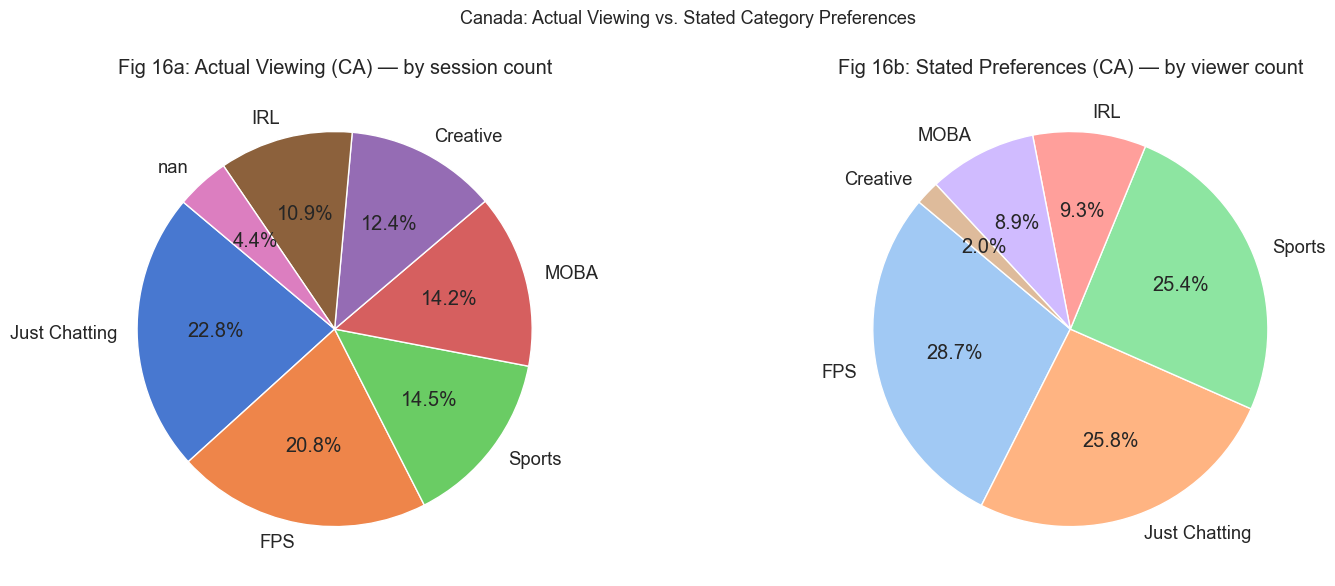

Top 5 actually watched:
stream_category
Just Chatting    334
FPS              304
Sports           212
MOBA             208
Creative         181
Name: count, dtype: int64

Top 5 stated preferred:
preferred_category
FPS              421
Just Chatting    379
Sports           373
IRL              136
MOBA             130
Name: count, dtype: int64


In [67]:
# Filter to Canadian viewers with stream metadata available
ca_sessions = merged_with_stream_info[merged_with_stream_info["country"] == "CA"]

# Actual viewing behaviour — by session count per category
actual = ca_sessions["stream_category"].value_counts()

# Stated preference — by viewer count per preferred_category
stated = merged_all[merged_all["country"] == "CA"]["preferred_category"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual
axes[0].pie(
    actual.values[:8], labels=actual.index[:8],
    autopct="%1.1f%%", startangle=140,
    colors=sns.color_palette("muted", 8)
)
axes[0].set_title("Fig 16a: Actual Viewing (CA) — by session count")

# Stated
axes[1].pie(
    stated.values[:8], labels=stated.index[:8],
    autopct="%1.1f%%", startangle=140,
    colors=sns.color_palette("pastel", 8)
)
axes[1].set_title("Fig 16b: Stated Preferences (CA) — by viewer count")

plt.suptitle("Canada: Actual Viewing vs. Stated Category Preferences", fontsize=13)
plt.tight_layout()
plt.show()

# Numerical alignment
print("Top 5 actually watched:")
print(actual.head(5))
print("\nTop 5 stated preferred:")
print(stated.head(5))


**Findings:** If the pie charts are similar, Canadian viewers are watching what they say they prefer which is a sign of healthy content alignment. If they differ, it suggests viewers are watching popular/trending content regardless of stated taste, or that content recommendations are pulling them toward particular categories.

**What additional data would help:** A timestamp for when `preferred_category` was last updated would allow tracking whether preferences change with viewing behaviour over time, enabling causal analysis of preference formation.

## Question 2: Does viewer subscription tier predict watching duration, or is the relationship driven by a third variable (age)?

**Hypothesis:** The apparent relationship between subscription tier and session duration (Task 6) may be confounded by age — older users both subscribe at higher tiers and have more time to watch. Controlling for age group allows us to test whether the tier–duration relationship holds within each cohort.

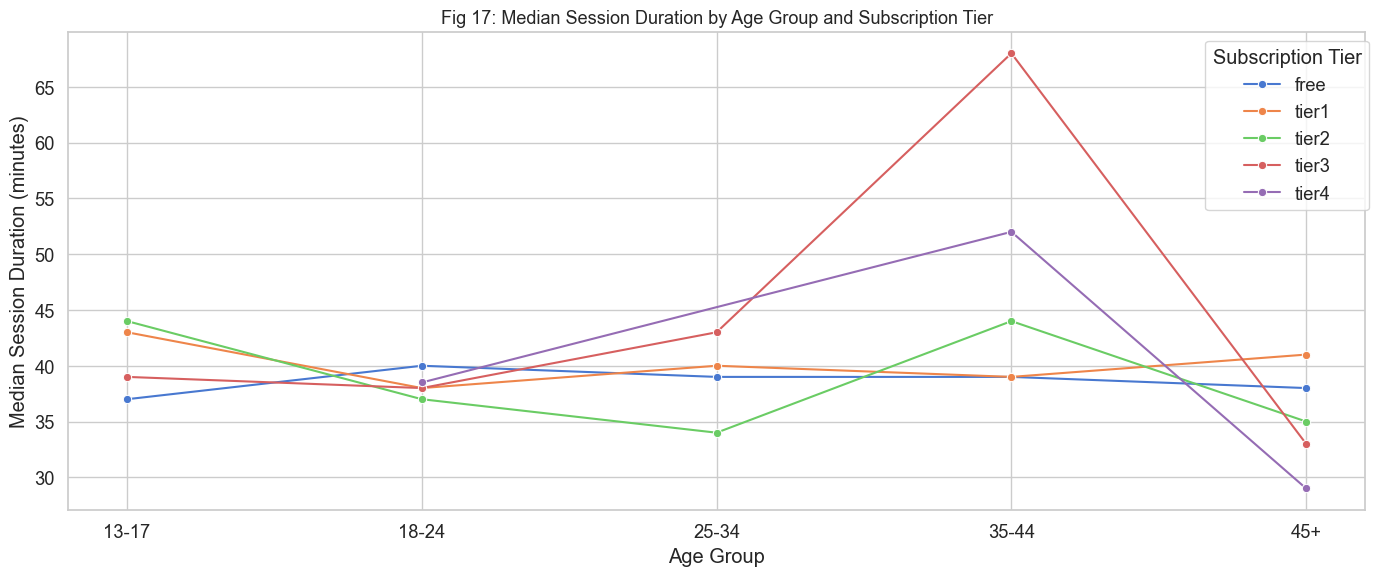

In [68]:
tier_order = ["free", "tier1", "tier2", "tier3", "tier4"]
age_groups = ["13-17", "18-24", "25-34", "35-44", "45+"]
colors = sns.color_palette("muted", len(tier_order))

# Mean session duration by tier, split by age group
plot_df = (
    merged_all
    .dropna(subset=["subscription_tier", "age_group"])
    [merged_all["duration_mins"].between(0, 300)]
    .groupby(["age_group", "subscription_tier"], observed=True)["duration_mins"]
    .median()
    .reset_index()
    .rename(columns={"duration_mins": "median_duration"})
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(
    data=plot_df,
    x="age_group", y="median_duration",
    hue="subscription_tier", hue_order=tier_order,
    marker="o", ax=ax, palette="muted"
)
ax.set_title("Fig 17: Median Session Duration by Age Group and Subscription Tier", fontsize=13)
ax.set_xlabel("Age Group")
ax.set_ylabel("Median Session Duration (minutes)")
ax.legend(title="Subscription Tier", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


In [69]:
# Summary table: does the tier ranking hold within each age group?
summary_pivot = plot_df.pivot(index="subscription_tier", columns="age_group", values="median_duration")
print("Median session duration (minutes) by tier × age group:")
print(summary_pivot.round(1).to_string())


Median session duration (minutes) by tier × age group:
age_group          13-17  18-24  25-34  35-44   45+
subscription_tier                                  
free                37.0   40.0   39.0   39.0  38.0
tier1               43.0   38.0   40.0   39.0  41.0
tier2               44.0   37.0   34.0   44.0  35.0
tier3               39.0   38.0   43.0   68.0  33.0
tier4                NaN   38.5    NaN   52.0  29.0


**Findings:** If higher tiers consistently show longer medians within each age group, the tier–duration relationship is robust and not simply explained by age. If the tier gradient collapses or reverses for certain age groups, age is a meaningful confounder.

**What additional data would help:** Timestamps showing when a user upgraded their subscription tier would allow longitudinal analysis — does upgrading cause longer sessions, or do already-heavy viewers upgrade because they value the platform more?

### Task 7: Summary Report

**Question 1 — Canada's preferred vs. actual categories:**
By comparing pie charts of actual session counts versus stated preferences for Canadian viewers, we can quantify the alignment between what viewers say they want and what they watch. Divergence would suggest content discoverability or recommendation effects. This is a practically actionable insight for a platform seeking to improve recommendation quality for Canadian users.

**Question 2 — Tier × age interaction on watch time:**
The line plot stratified by age group reveals whether the subscription tier–duration relationship is consistent across demographics or driven by confounding. Finding a consistent tier gradient across all age groups would strengthen the claim that paid subscribers are genuinely more engaged, regardless of age. The pivot table makes any reversals or exceptions immediately visible.

**Common limitation:** Both analyses rely on observational data with no experimental control. Correlation between tier and watch time cannot establish causality — self-selection (more engaged users buying higher tiers) and reverse causality (higher-tier benefits encouraging longer viewing) are both plausible.


# Task 8: EDA Presentation (Insight Report)

Summarize your findings in a polished format:  
- Create 3–4 slides or a single-page report highlighting your most important insights  
- Include at least 2 charts and interpret them using clear, plain language  
- Apply Tufte’s principles: minimize chartjunk, maximize data-to-ink ratio, and ensure clear labeling  